In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

import numpy as np
import pandas as pd

def greedy_complete_filter(
    df: pd.DataFrame,
    cols=None,
    id_cols=None,
    skip_cols=None,
    stop_when_no_na_left: bool = True,
):
    if id_cols is None:
        id_cols = []
    if skip_cols is None:
        skip_cols = []
    if cols is None:
        cols = list(df.columns)

    # remove id + skip from consideration
    skip_set = set(id_cols) | set(skip_cols)
    cols = [c for c in cols if c in df.columns and c not in skip_set]

    keep = np.ones(len(df), dtype=bool)
    steps = []
    step_i = 0

    while cols and keep.any():
        step_i += 1

        na_counts = {c: int(df.loc[keep, c].isna().sum()) for c in cols}
        min_na = min(na_counts.values())
        pick = next(c for c in cols if na_counts[c] == min_na)  # tie-break: current order

        n_before = int(keep.sum())
        keep2 = keep & df[pick].notna().to_numpy()
        n_after = int(keep2.sum())

        steps.append({
            "step": step_i,
            "field": pick,
            "n_before": n_before,
            "n_after": n_after,
            "dropped": n_before - n_after,
            "na_in_field_before": na_counts[pick],
            "prop_remaining": n_after / len(df),
        })

        keep = keep2
        cols.remove(pick)

        if stop_when_no_na_left and cols and keep.any():
            na_left = [int(df.loc[keep, c].isna().sum()) for c in cols]
            if all(x == 0 for x in na_left):
                n_cur = int(keep.sum())
                for j, c in enumerate(cols, start=1):
                    steps.append({
                        "step": step_i + j,
                        "field": c,
                        "n_before": n_cur,
                        "n_after": n_cur,
                        "dropped": 0,
                        "na_in_field_before": 0,
                        "prop_remaining": n_cur / len(df),
                    })
                break

    steps_df = pd.DataFrame(steps)
    return {
        "steps": steps_df,
        "row_mask": keep,
        "filtered": df.loc[keep].copy(),
        "chosen_order": steps_df["field"].tolist() if not steps_df.empty else [],
        "skipped_cols": sorted([c for c in skip_cols if c in df.columns]),
    }

# -------------------------
# Plotting helpers (optional)
# -------------------------
def plot_attrition(steps_df, wrap_width=22, dpi=160):
    if steps_df.empty:
        print("No steps to plot.")
        return

    # ---------- Plot 1: rows remaining ----------
    fig, ax = plt.subplots(figsize=(14, 6), dpi=dpi)
    ax.plot(steps_df["step"], steps_df["n_after"], marker="o")
    ax.set_xlabel("Greedy step")
    ax.set_ylabel("Rows remaining")
    ax.set_title("Attrition")
    ax.set_xticks(steps_df["step"])
    ax.tick_params(axis="x", labelrotation=0, labelsize=8)
    ax.grid(True, which="both", axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

    # ---------- Plot 2: drops per step ----------
    # dynamic height to avoid crowded y-labels
    n = len(steps_df)
    height = max(8, 0.35 * n)  # adjust 0.35 if you want even more spacing

    fig, ax = plt.subplots(figsize=(14, height), dpi=dpi)

    dropped = steps_df["dropped"].to_numpy()
    y = np.arange(n)

    # Wrap long labels to multiple lines
    labels = [
        "\n".join(textwrap.wrap(str(s), width=wrap_width))
        for s in steps_df["field"].tolist()
    ]

    ax.barh(y, dropped)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Rows dropped at this step")
    ax.set_title("Drop in N at each greedy step")

    # Log-like scale that can handle zeros:
    # - 'symlog' behaves linear near 0 and log further out
    ax.set_xscale("symlog", linthresh=1)

    ax.grid(True, which="both", axis="x", alpha=0.3)

    # Optional: annotate exact numbers (works best if not too many bars)
    # for i, v in enumerate(dropped):
    #     if v > 0:
    #         ax.text(v, i, f" {int(v):,}", va="center", fontsize=8)

    fig.tight_layout()
    plt.show()

def plot_missing_overview(df: pd.DataFrame, sample_n: int = 5000):
    """
    Quick missingness viz:
    - heatmap of missingness on a sample (seaborn)
    - UpSet plot (optional, requires upsetplot)
    """
    import matplotlib.pyplot as plt

    dsmall = df.sample(sample_n, random_state=0) if len(df) > sample_n else df

    # Heatmap-like view: missing = 1, present = 0
    try:
        import seaborn as sns
        plt.figure(figsize=(12, 5))
        sns.heatmap(dsmall.isna(), cbar=False)
        plt.title(f"Missingness heatmap (sample n={len(dsmall)})")
        plt.xlabel("Columns")
        plt.ylabel("Rows (sampled)")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Heatmap skipped (install seaborn). Error:", e)

    # UpSet plot of missingness patterns (can be expensive if many cols)
    try:
        from upsetplot import UpSet, from_indicators
        indicators = dsmall.isna()
        upset_data = from_indicators(indicators.columns, indicators)
        plt.figure()
        UpSet(upset_data, show_counts=True).plot()
        plt.suptitle("Missingness pattern UpSet plot (sampled)")
        plt.show()
    except Exception as e:
        print("UpSet skipped (pip install upsetplot). Error:", e)

In [9]:
import os
os.getcwd()

'/scratch/liuhon33/parallel/AGPMicrobiomeHostPredictions/variable_mapping'

In [11]:
# -------------------------
# Example usage
# -------------------------
df = pd.read_csv("ukb_as_agp_metadata.csv")
res = greedy_complete_filter(df, id_cols=["sample_name"])
df_greedy_complete = res["filtered"]

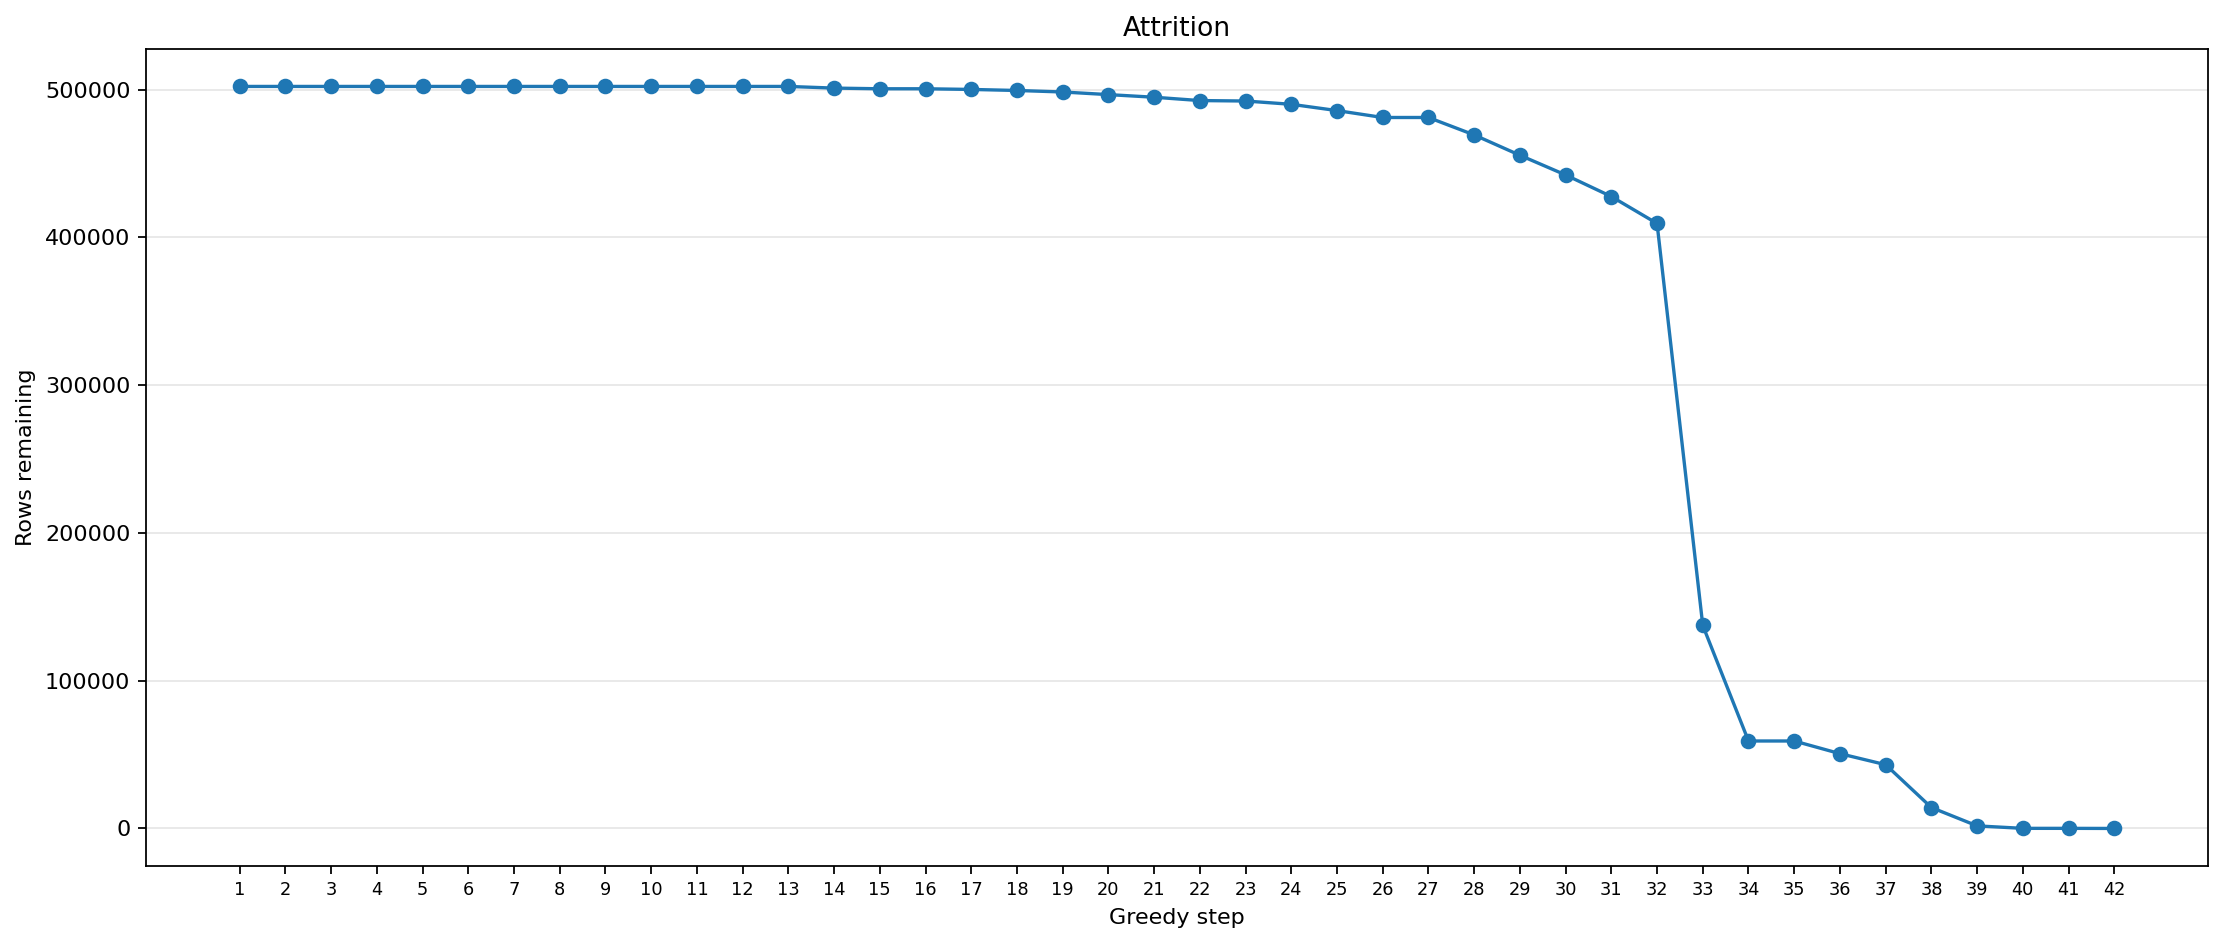

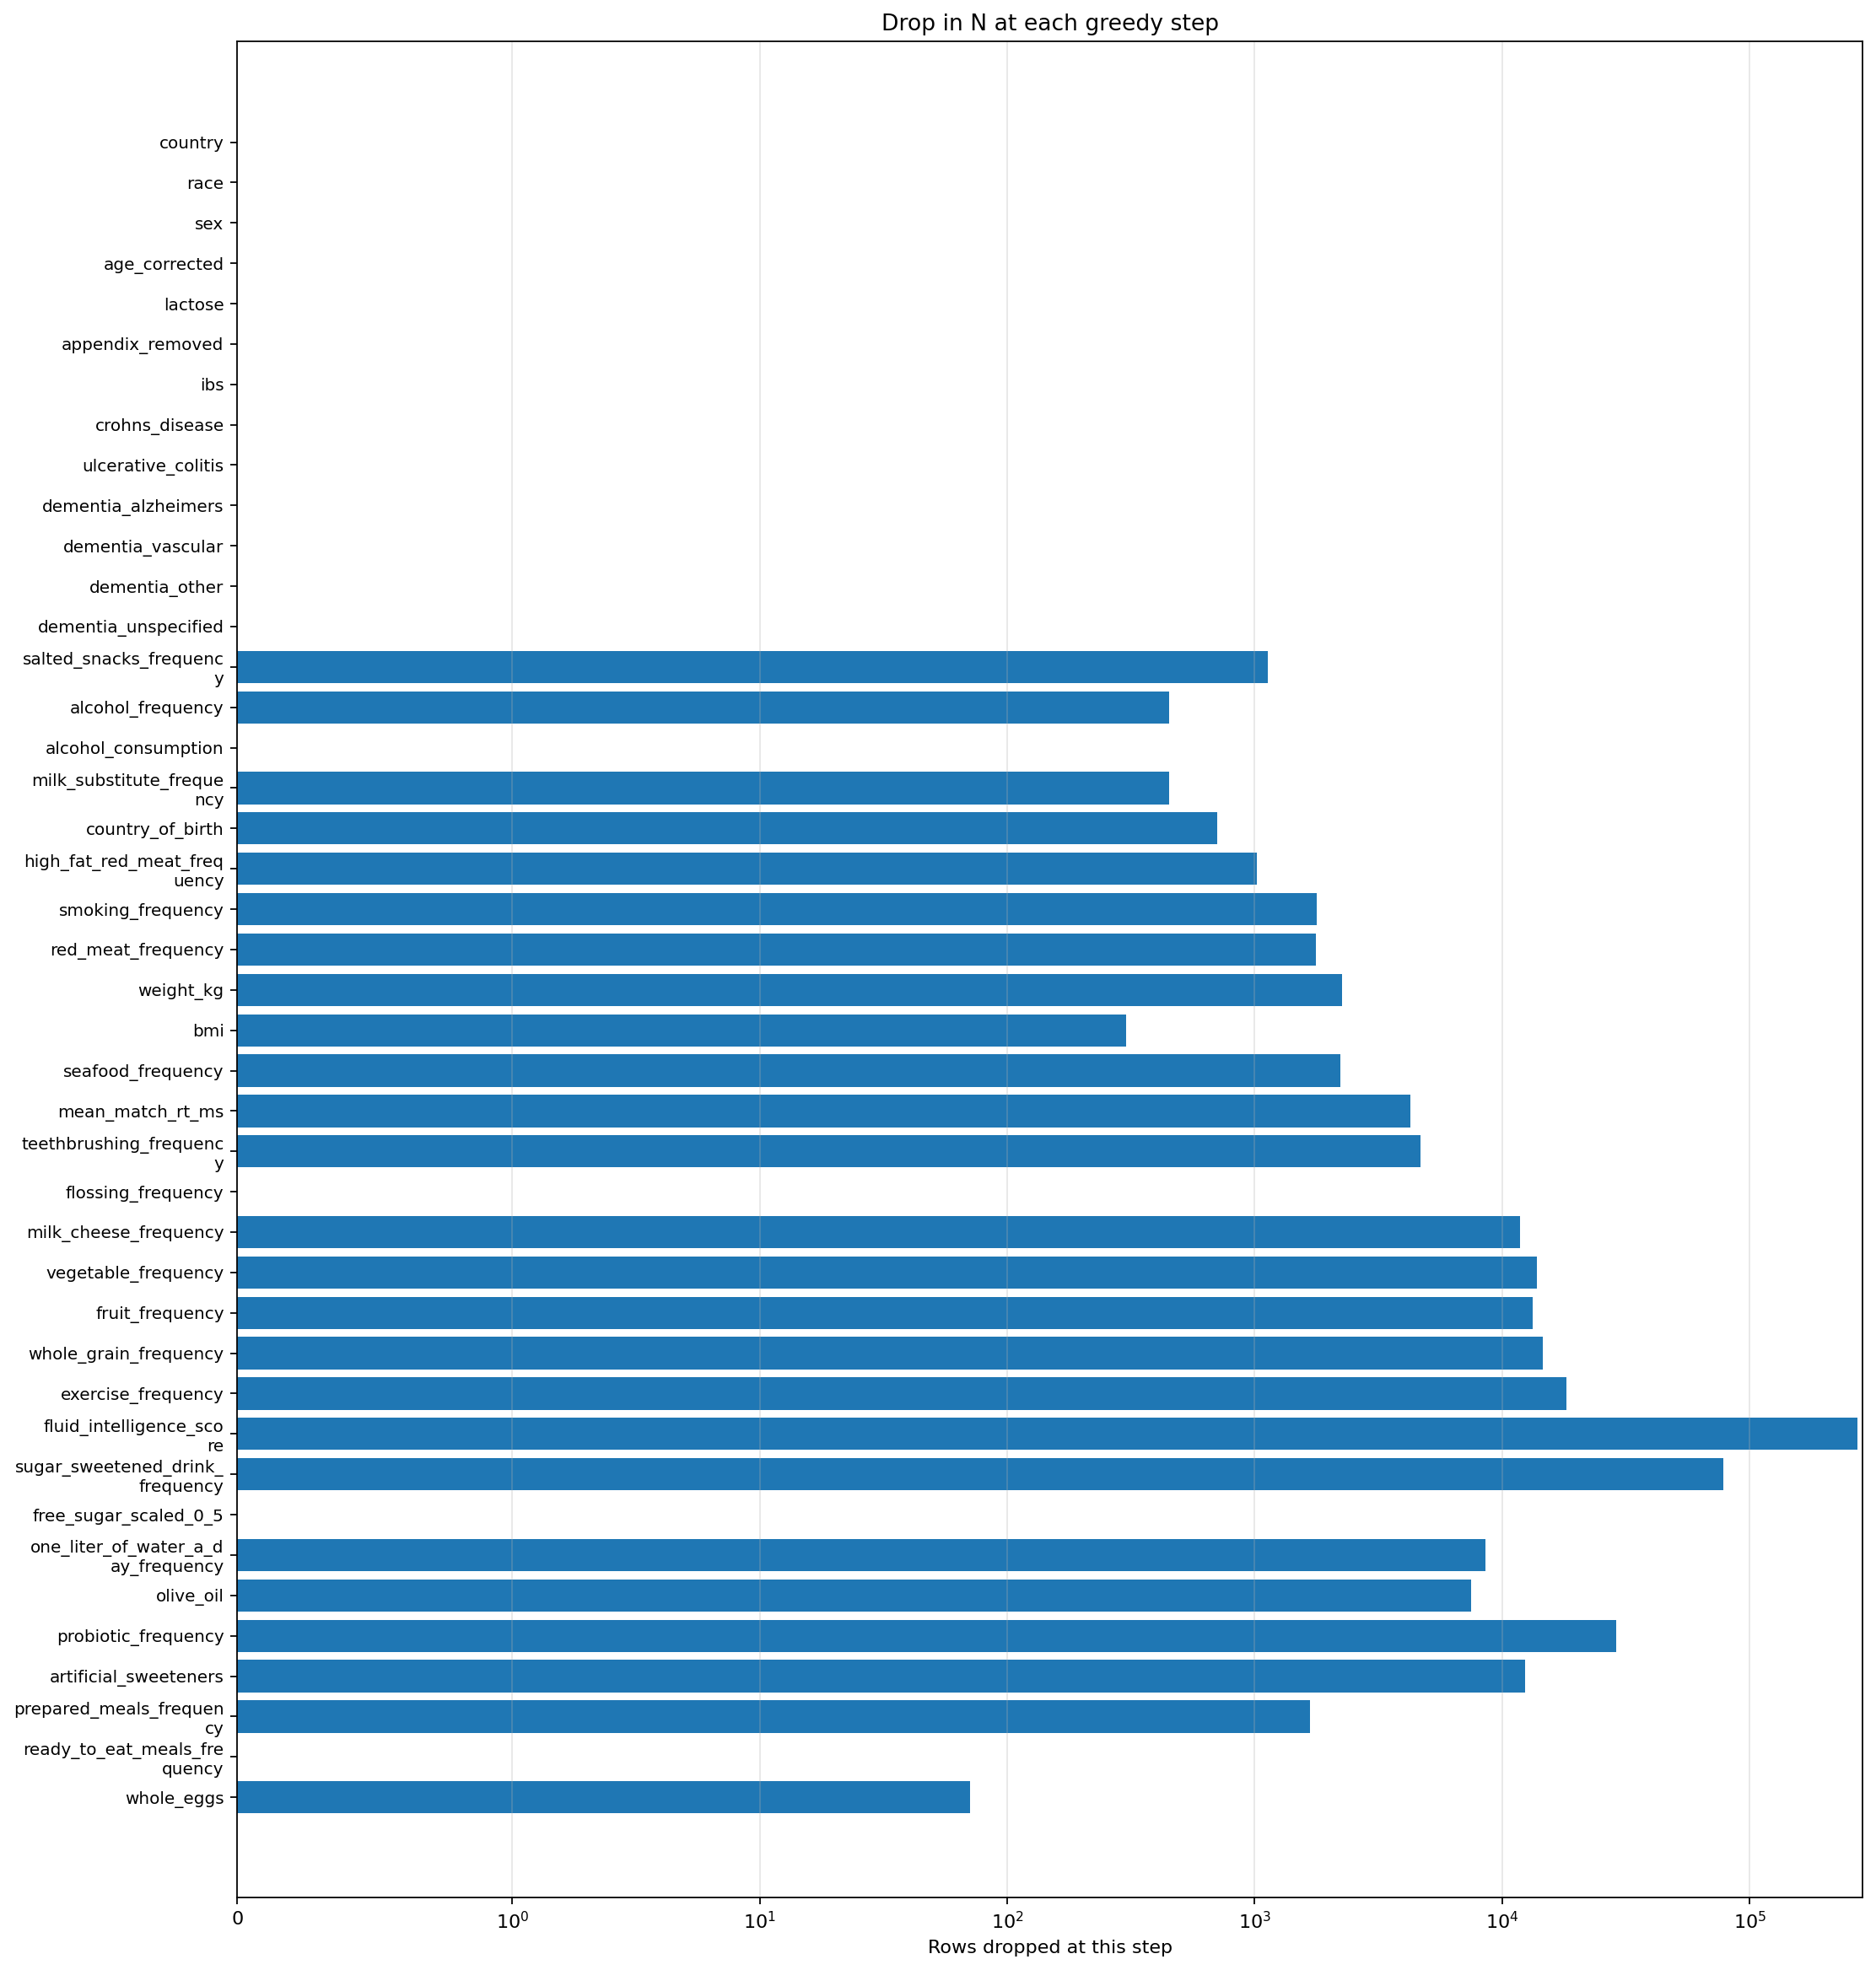

In [5]:
plot_attrition(res["steps"])

In [6]:
print(res["steps"])

    step                               field  n_before  n_after  dropped  \
0      1                             country    502244   502244        0   
1      2                                race    502244   502244        0   
2      3                                 sex    502244   502244        0   
3      4                       age_corrected    502244   502244        0   
4      5                             lactose    502244   502244        0   
5      6                    appendix_removed    502244   502244        0   
6      7                                 ibs    502244   502244        0   
7      8                      crohns_disease    502244   502244        0   
8      9                  ulcerative_colitis    502244   502244        0   
9     10                 dementia_alzheimers    502244   502244        0   
10    11                   dementia_vascular    502244   502244        0   
11    12                      dementia_other    502244   502244        0   
12    13    

    step                               field  n_before  n_after  dropped  \
0      1                         sample_name    502244   502244        0   
1      2                             country    502244   502244        0   
2      3                                race    502244   502244        0   
3      4                                 sex    502244   502244        0   
4      5                       age_corrected    502244   502244        0   
5      6                             lactose    502244   502244        0   
6      7                    appendix_removed    502244   502244        0   
7      8                                 ibs    502244   502244        0   
8      9                      crohns_disease    502244   502244        0   
9     10                  ulcerative_colitis    502244   502244        0   
10    11                 dementia_alzheimers    502244   502244        0   
11    12                   dementia_vascular    502244   502244        0   
12    13    

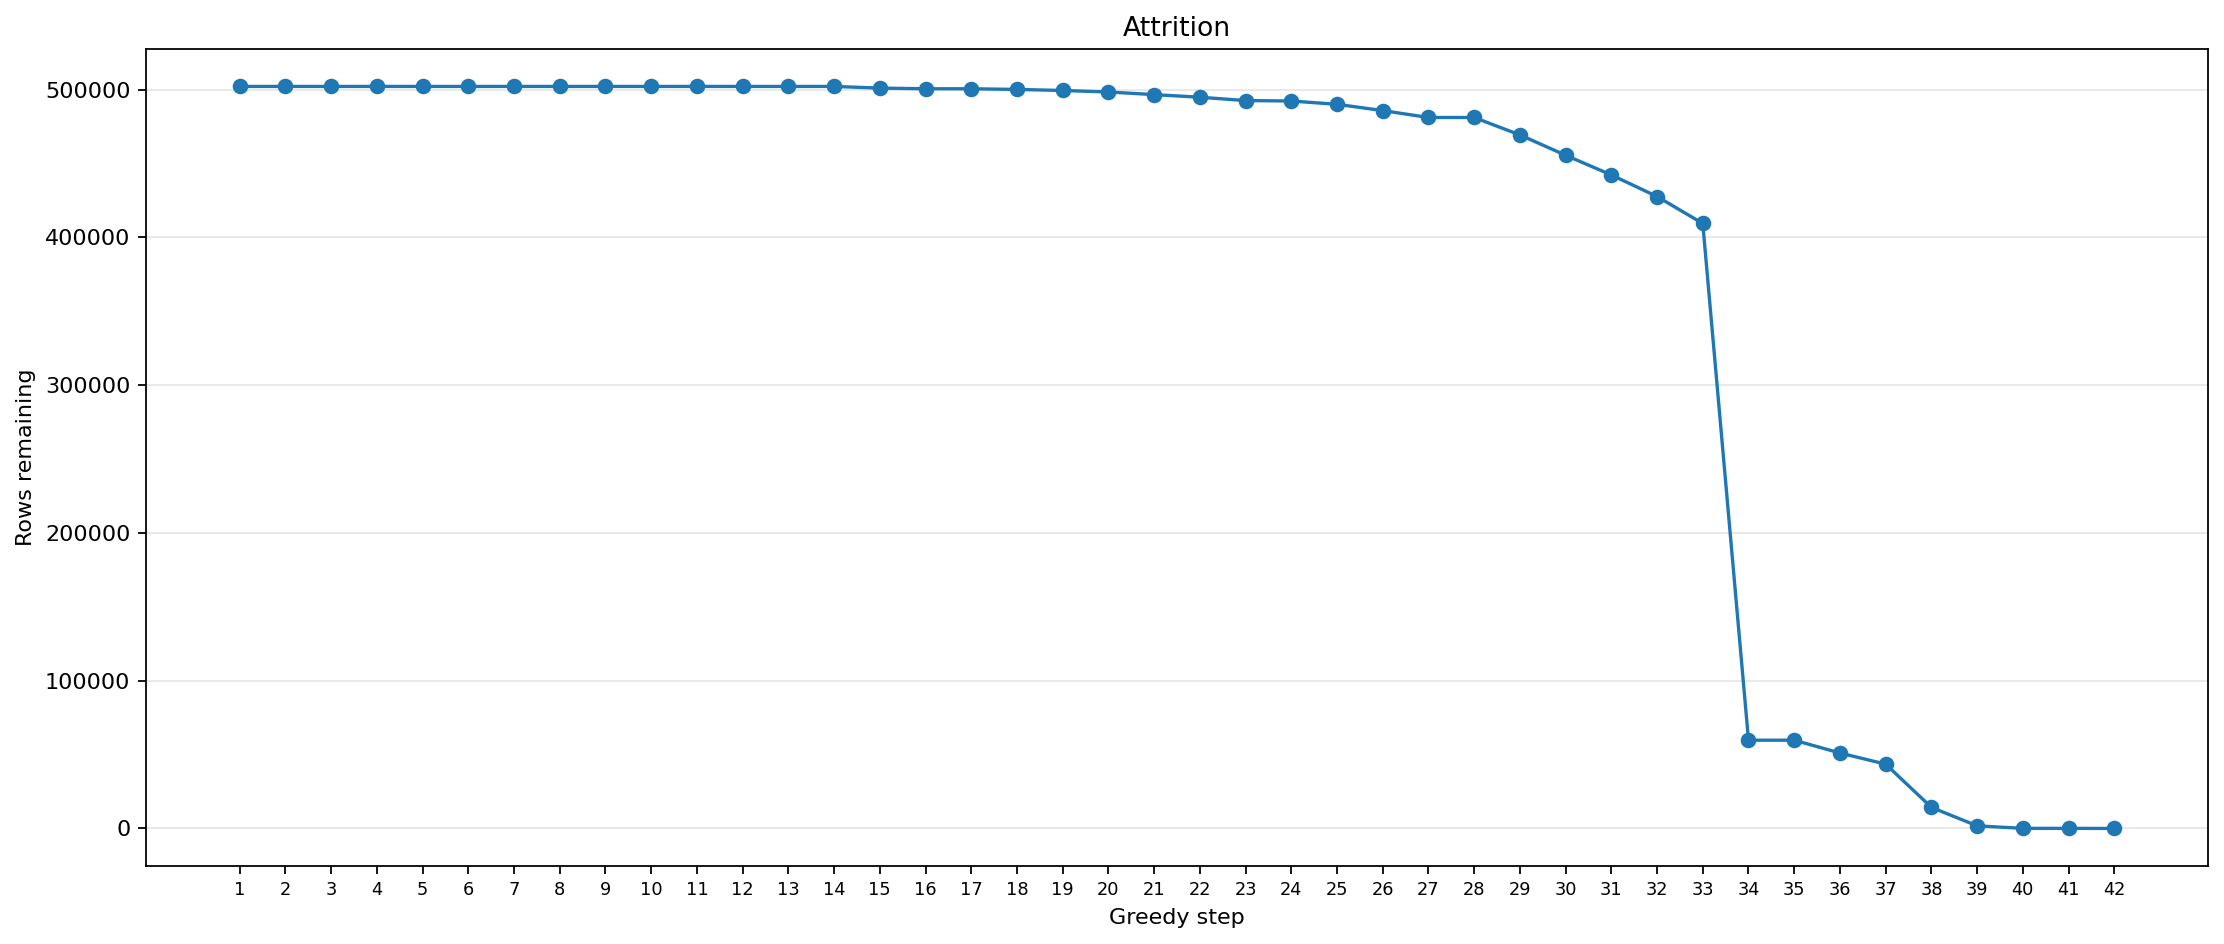

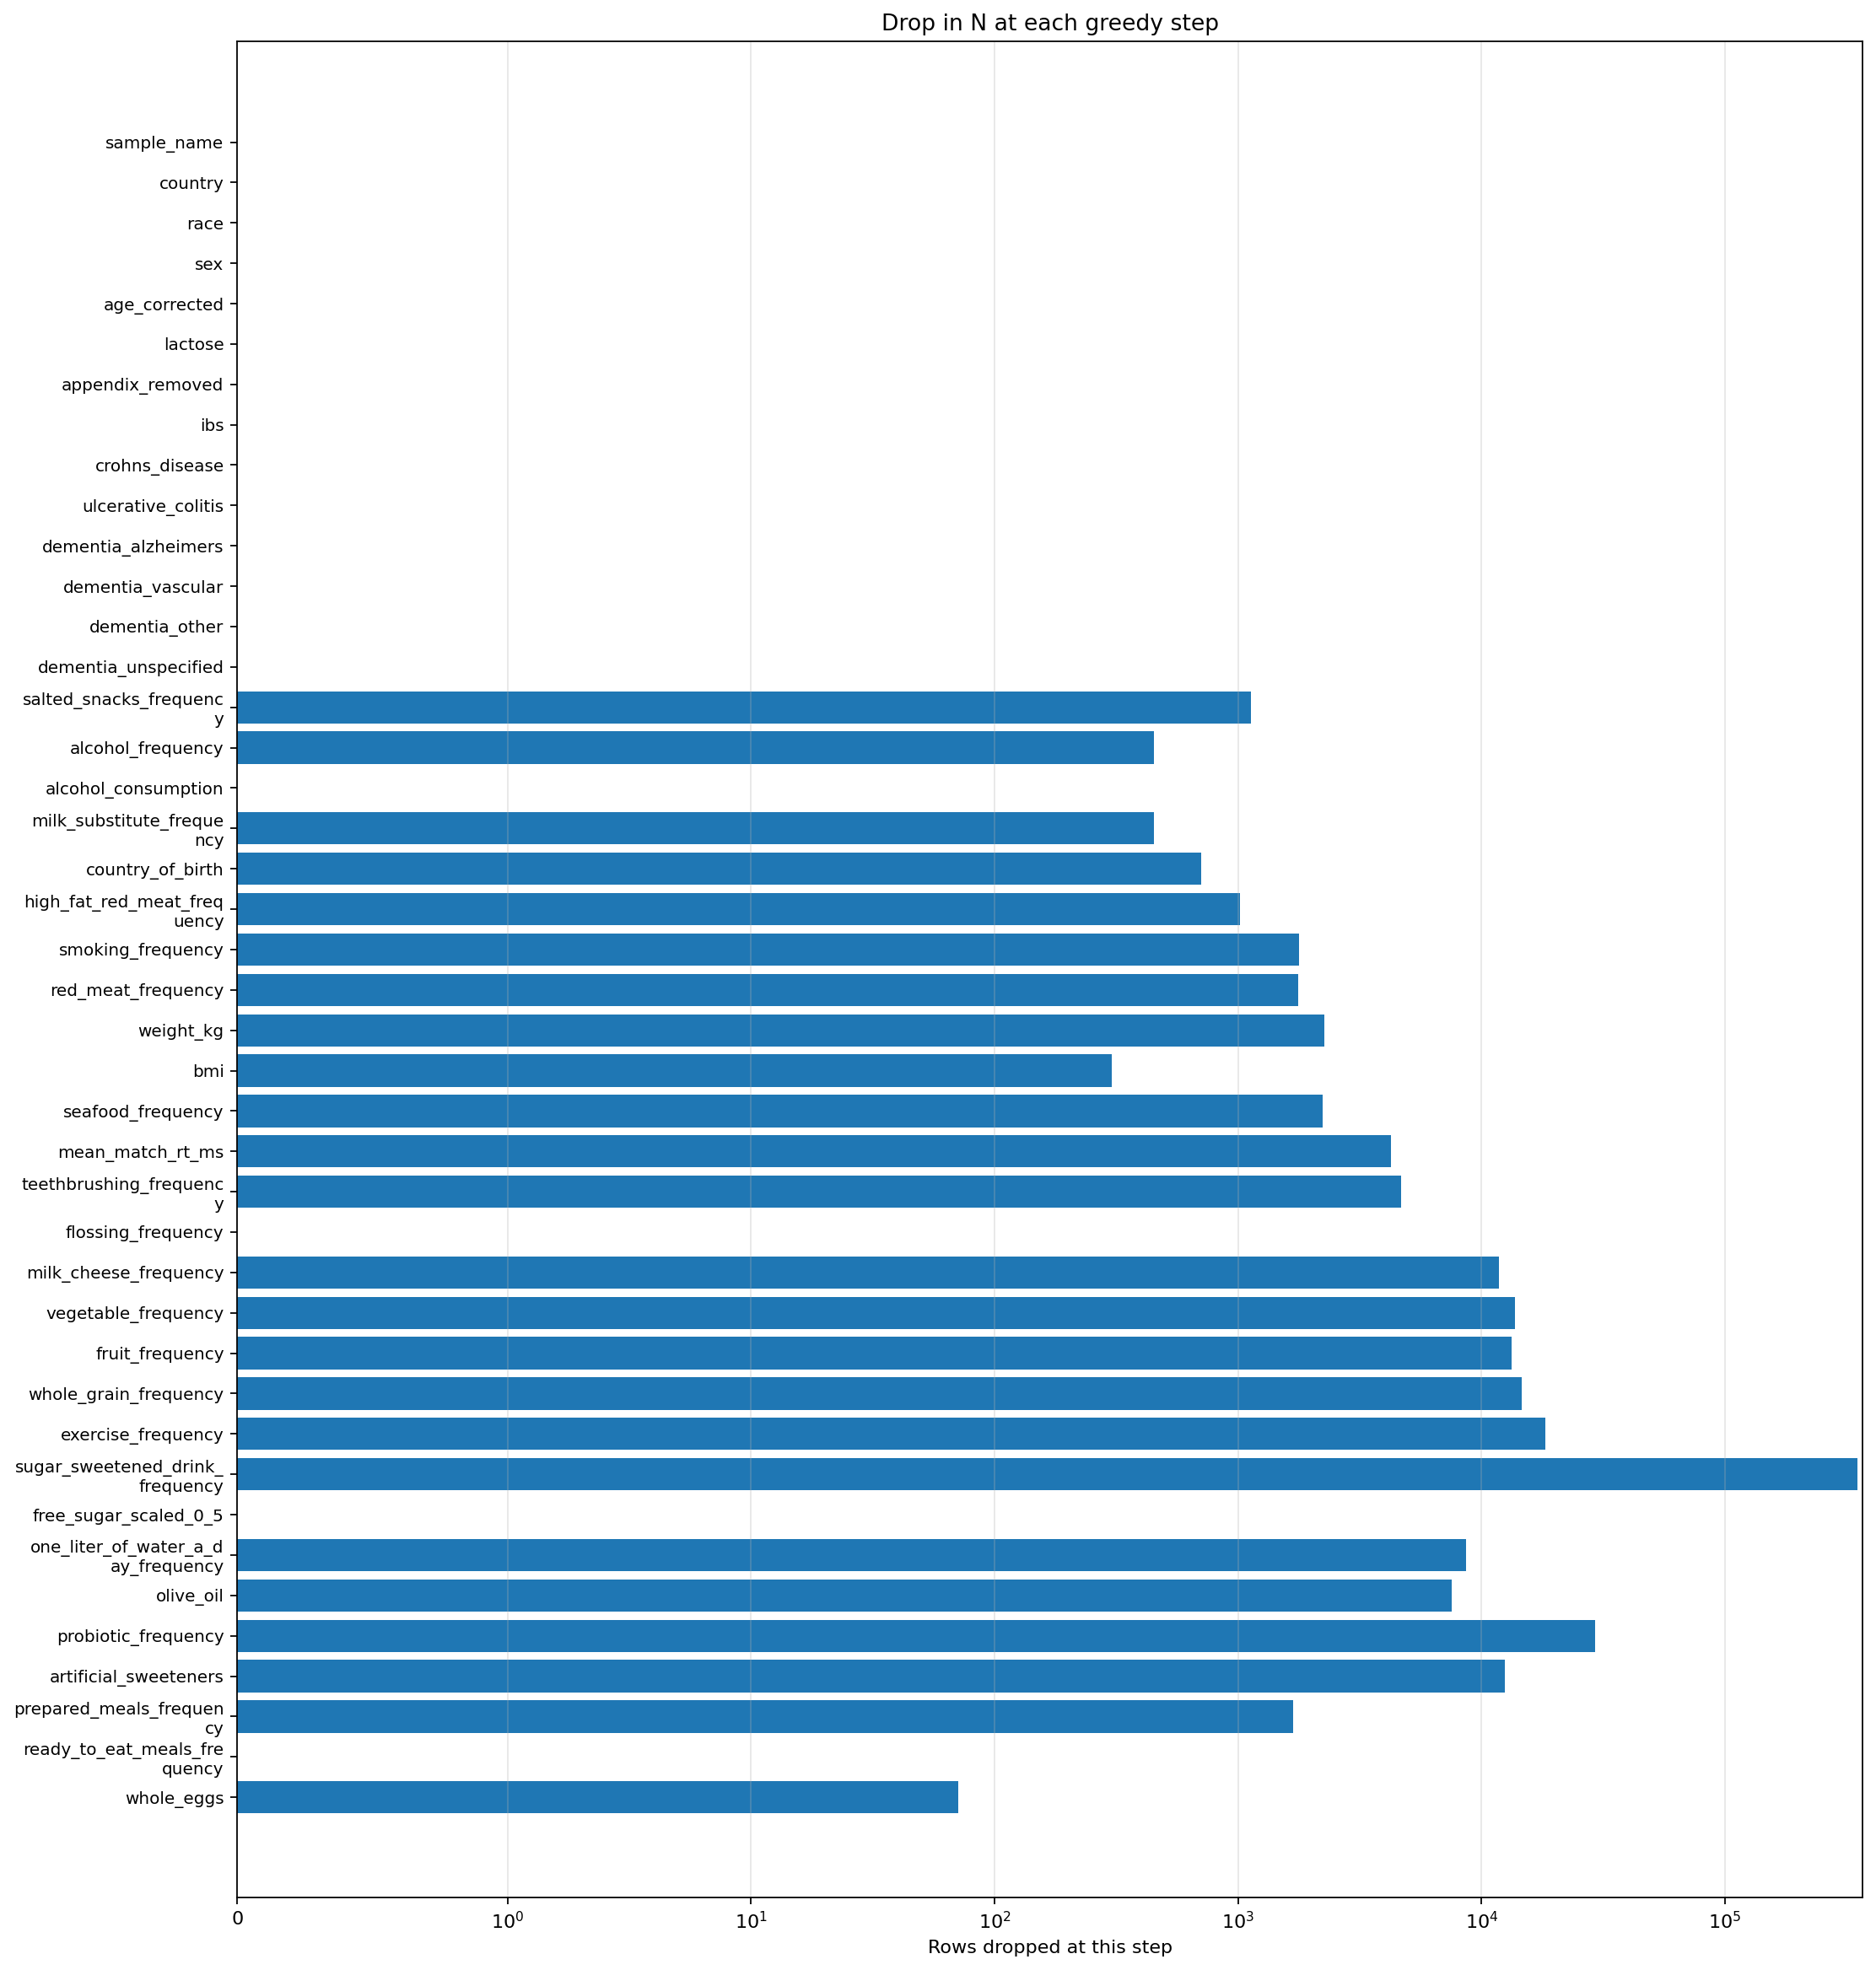

In [15]:
skip_cols = ["fluid_intelligence_score"]  # whatever you want to ignore entirely

res = greedy_complete_filter(df, id_cols=["eid"], skip_cols=skip_cols)
steps_df = res["steps"]
print(steps_df)
plot_attrition(steps_df)

    step                               field  n_before  n_after  dropped  \
0      1                         sample_name    502244   502244        0   
1      2                             country    502244   502244        0   
2      3                                race    502244   502244        0   
3      4                                 sex    502244   502244        0   
4      5                       age_corrected    502244   502244        0   
5      6                             lactose    502244   502244        0   
6      7                    appendix_removed    502244   502244        0   
7      8                                 ibs    502244   502244        0   
8      9                      crohns_disease    502244   502244        0   
9     10                  ulcerative_colitis    502244   502244        0   
10    11                 dementia_alzheimers    502244   502244        0   
11    12                   dementia_vascular    502244   502244        0   
12    13    

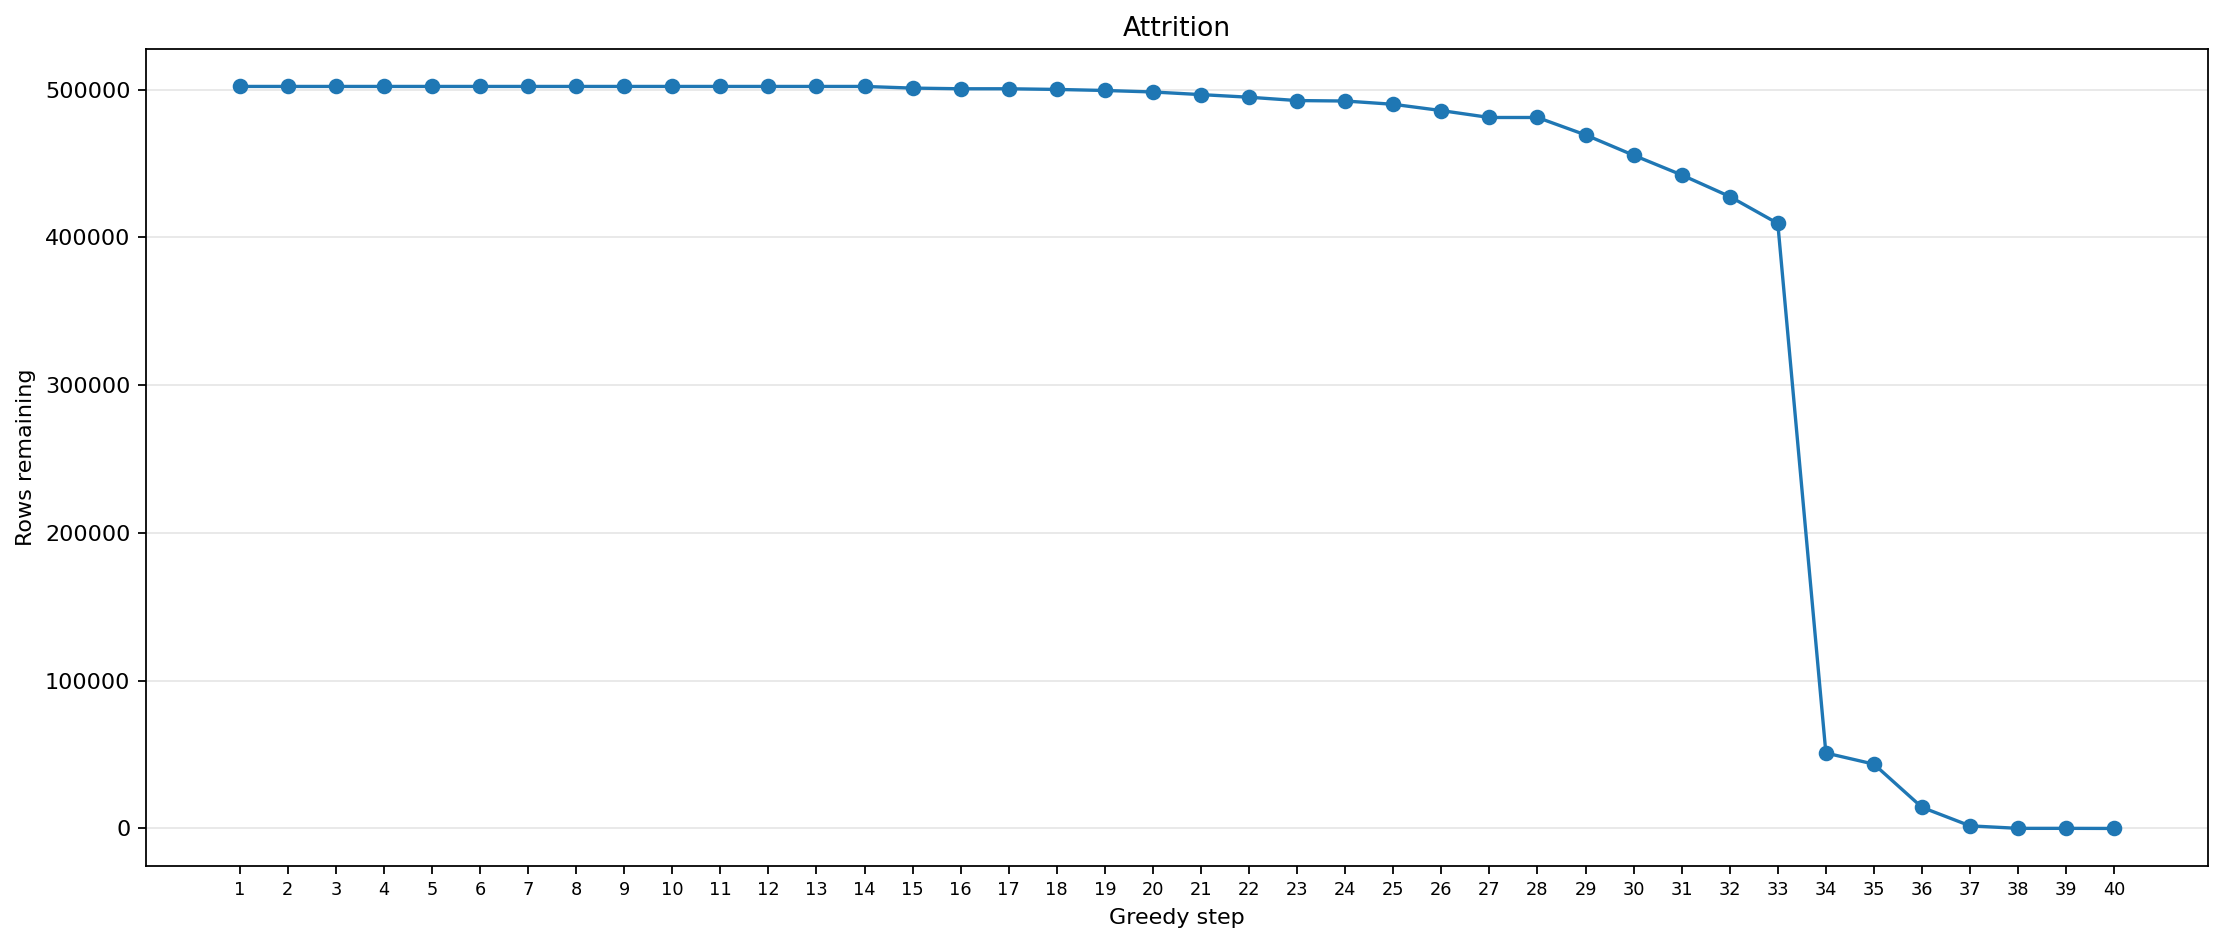

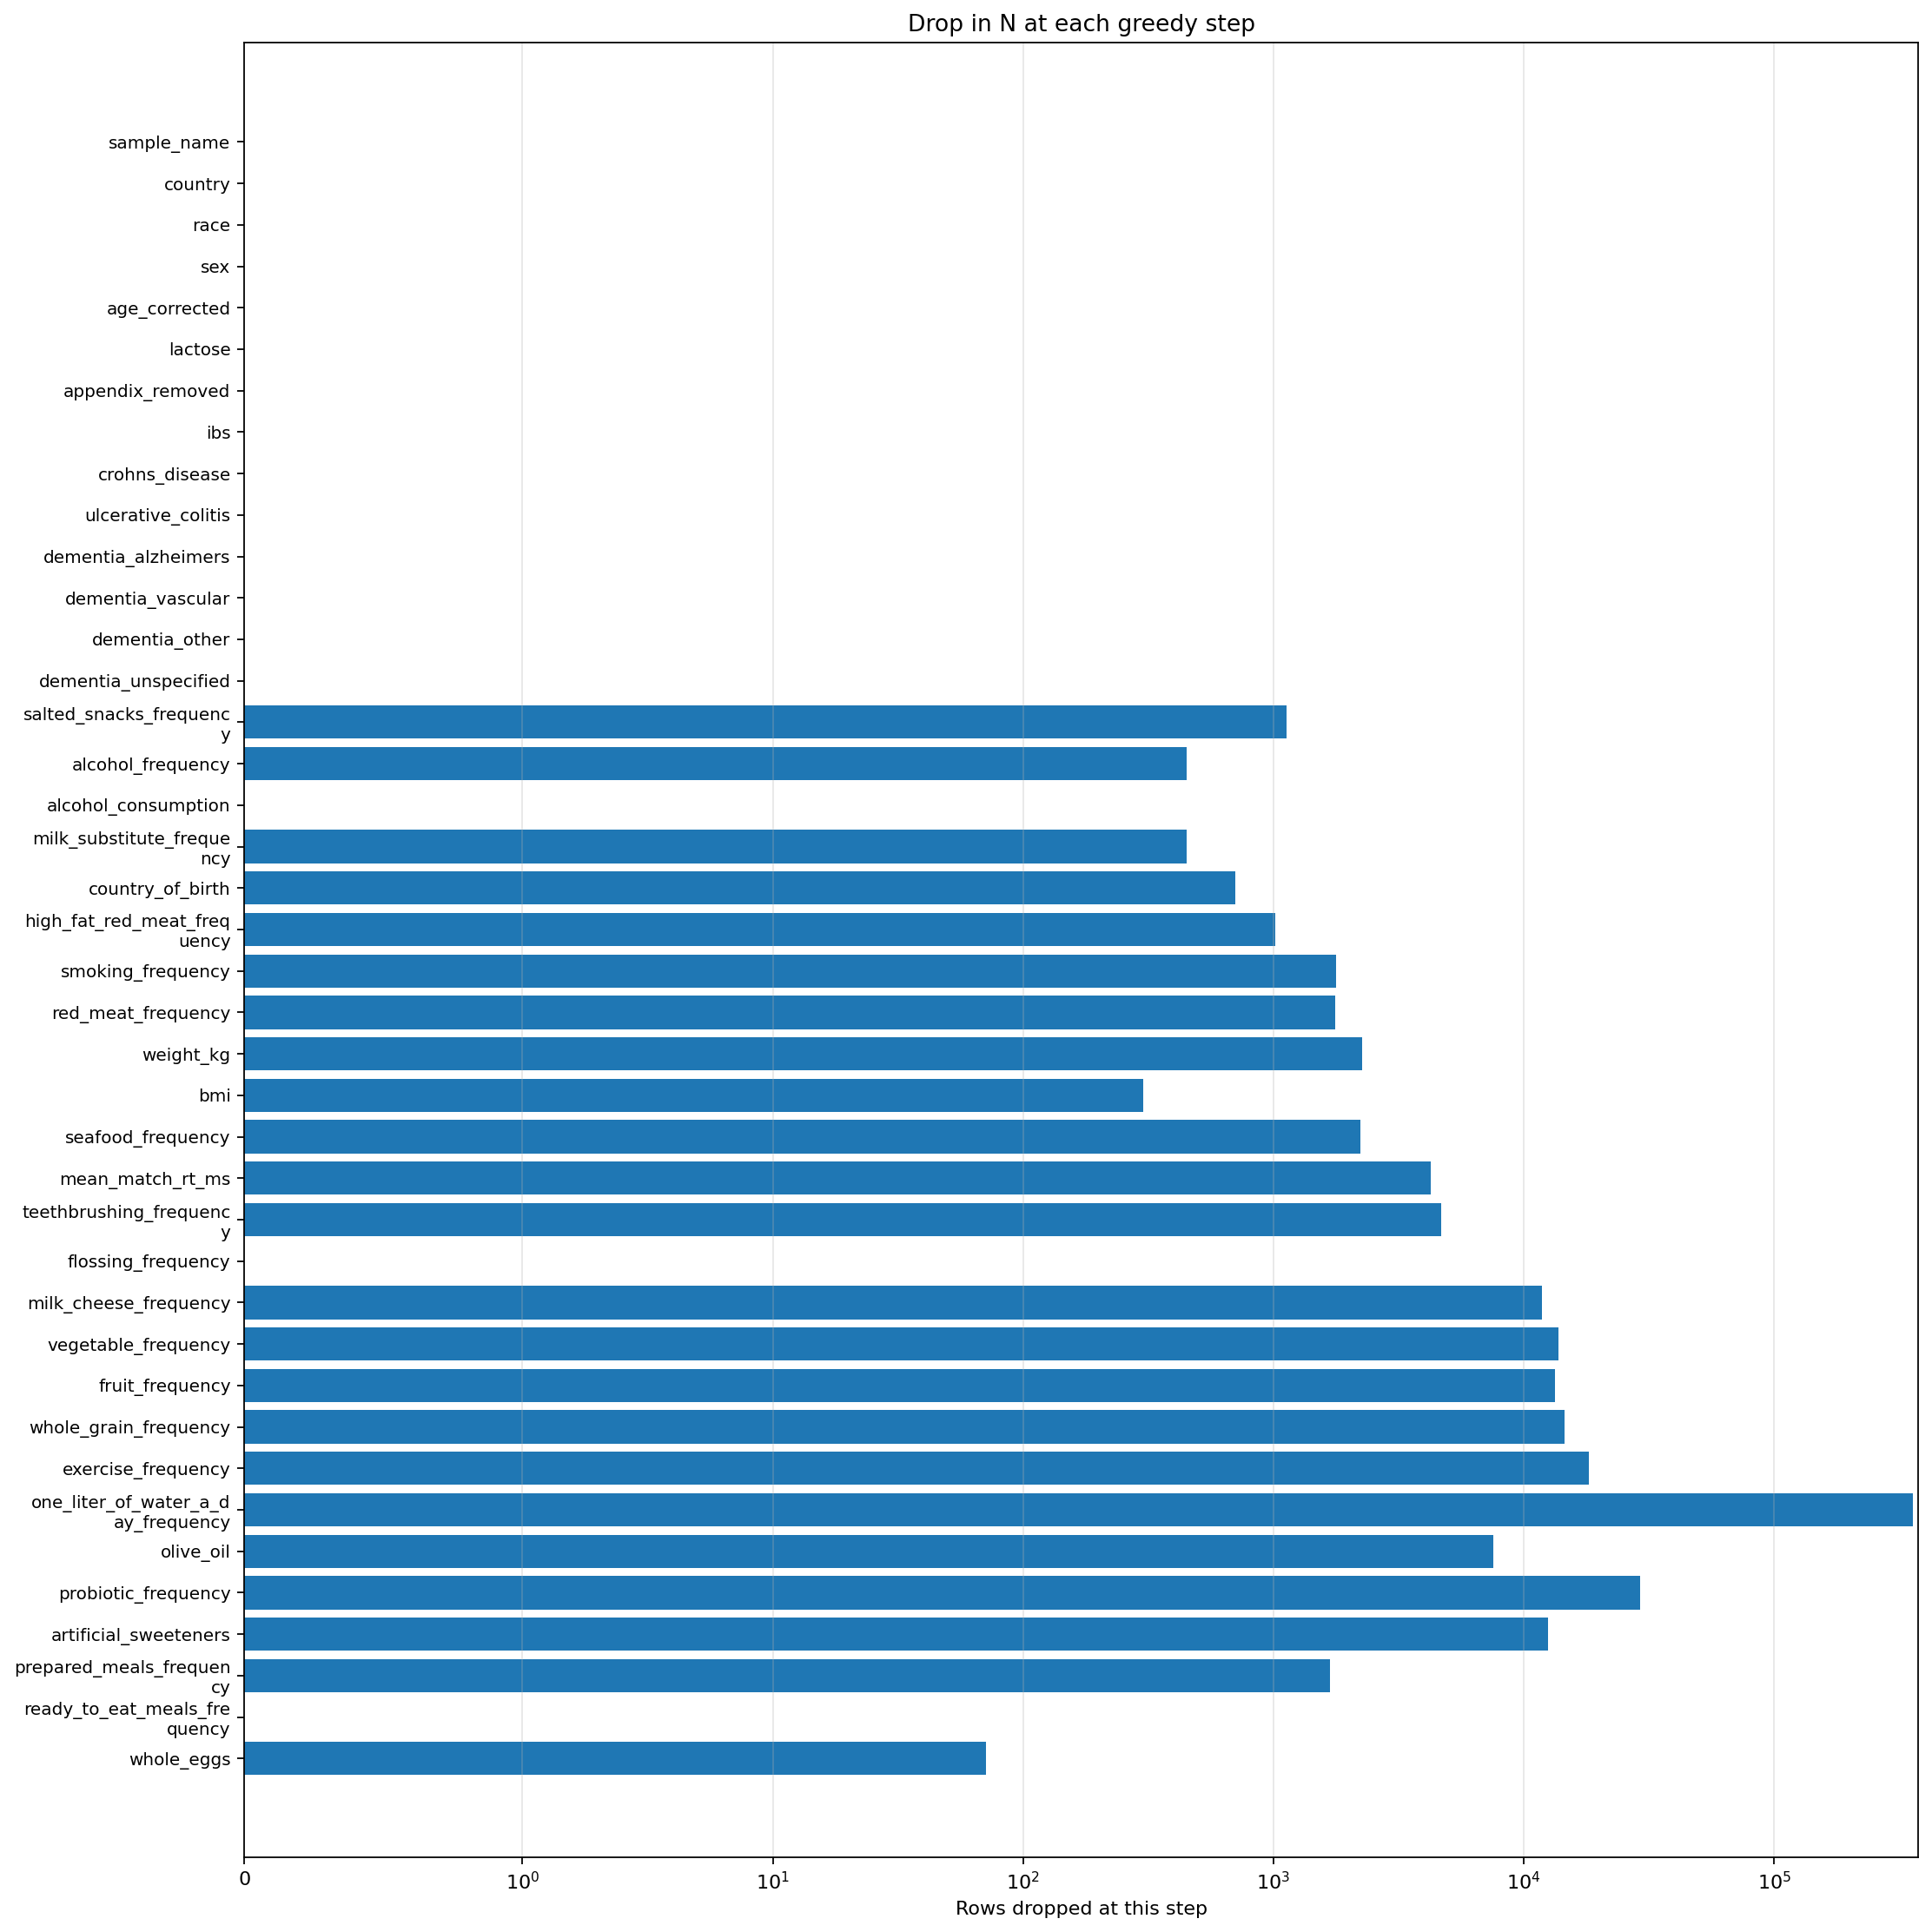

In [16]:
skip_cols = ["fluid_intelligence_score", "sugar_sweetened_drink_frequency", "free_sugar_scaled_0_5"]  # whatever you want to ignore entirely

res = greedy_complete_filter(df, id_cols=["eid"], skip_cols=skip_cols)
steps_df = res["steps"]
print(steps_df)
plot_attrition(steps_df)

    step                               field  n_before  n_after  dropped  \
0      1                         sample_name    502244   502244        0   
1      2                             country    502244   502244        0   
2      3                                race    502244   502244        0   
3      4                                 sex    502244   502244        0   
4      5                       age_corrected    502244   502244        0   
5      6                             lactose    502244   502244        0   
6      7                    appendix_removed    502244   502244        0   
7      8                                 ibs    502244   502244        0   
8      9                      crohns_disease    502244   502244        0   
9     10                  ulcerative_colitis    502244   502244        0   
10    11                 dementia_alzheimers    502244   502244        0   
11    12                   dementia_vascular    502244   502244        0   
12    13    

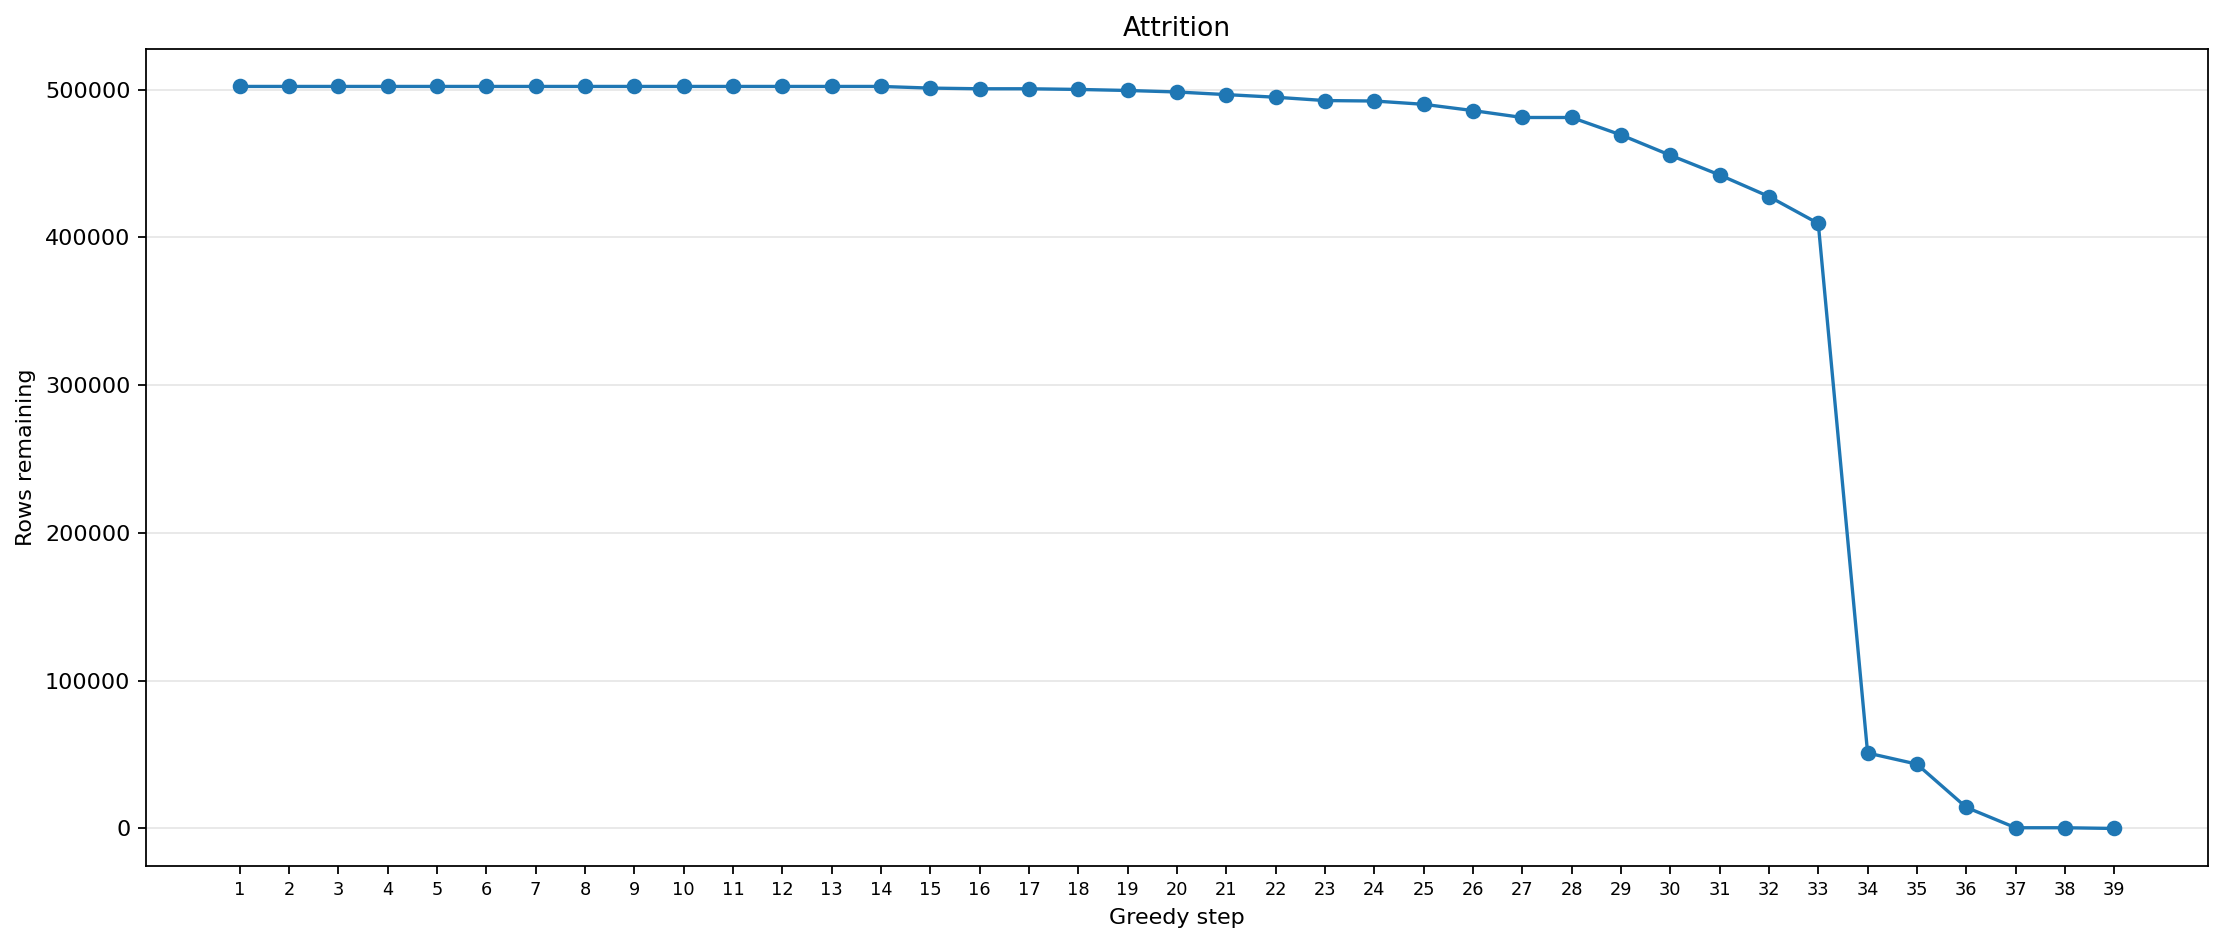

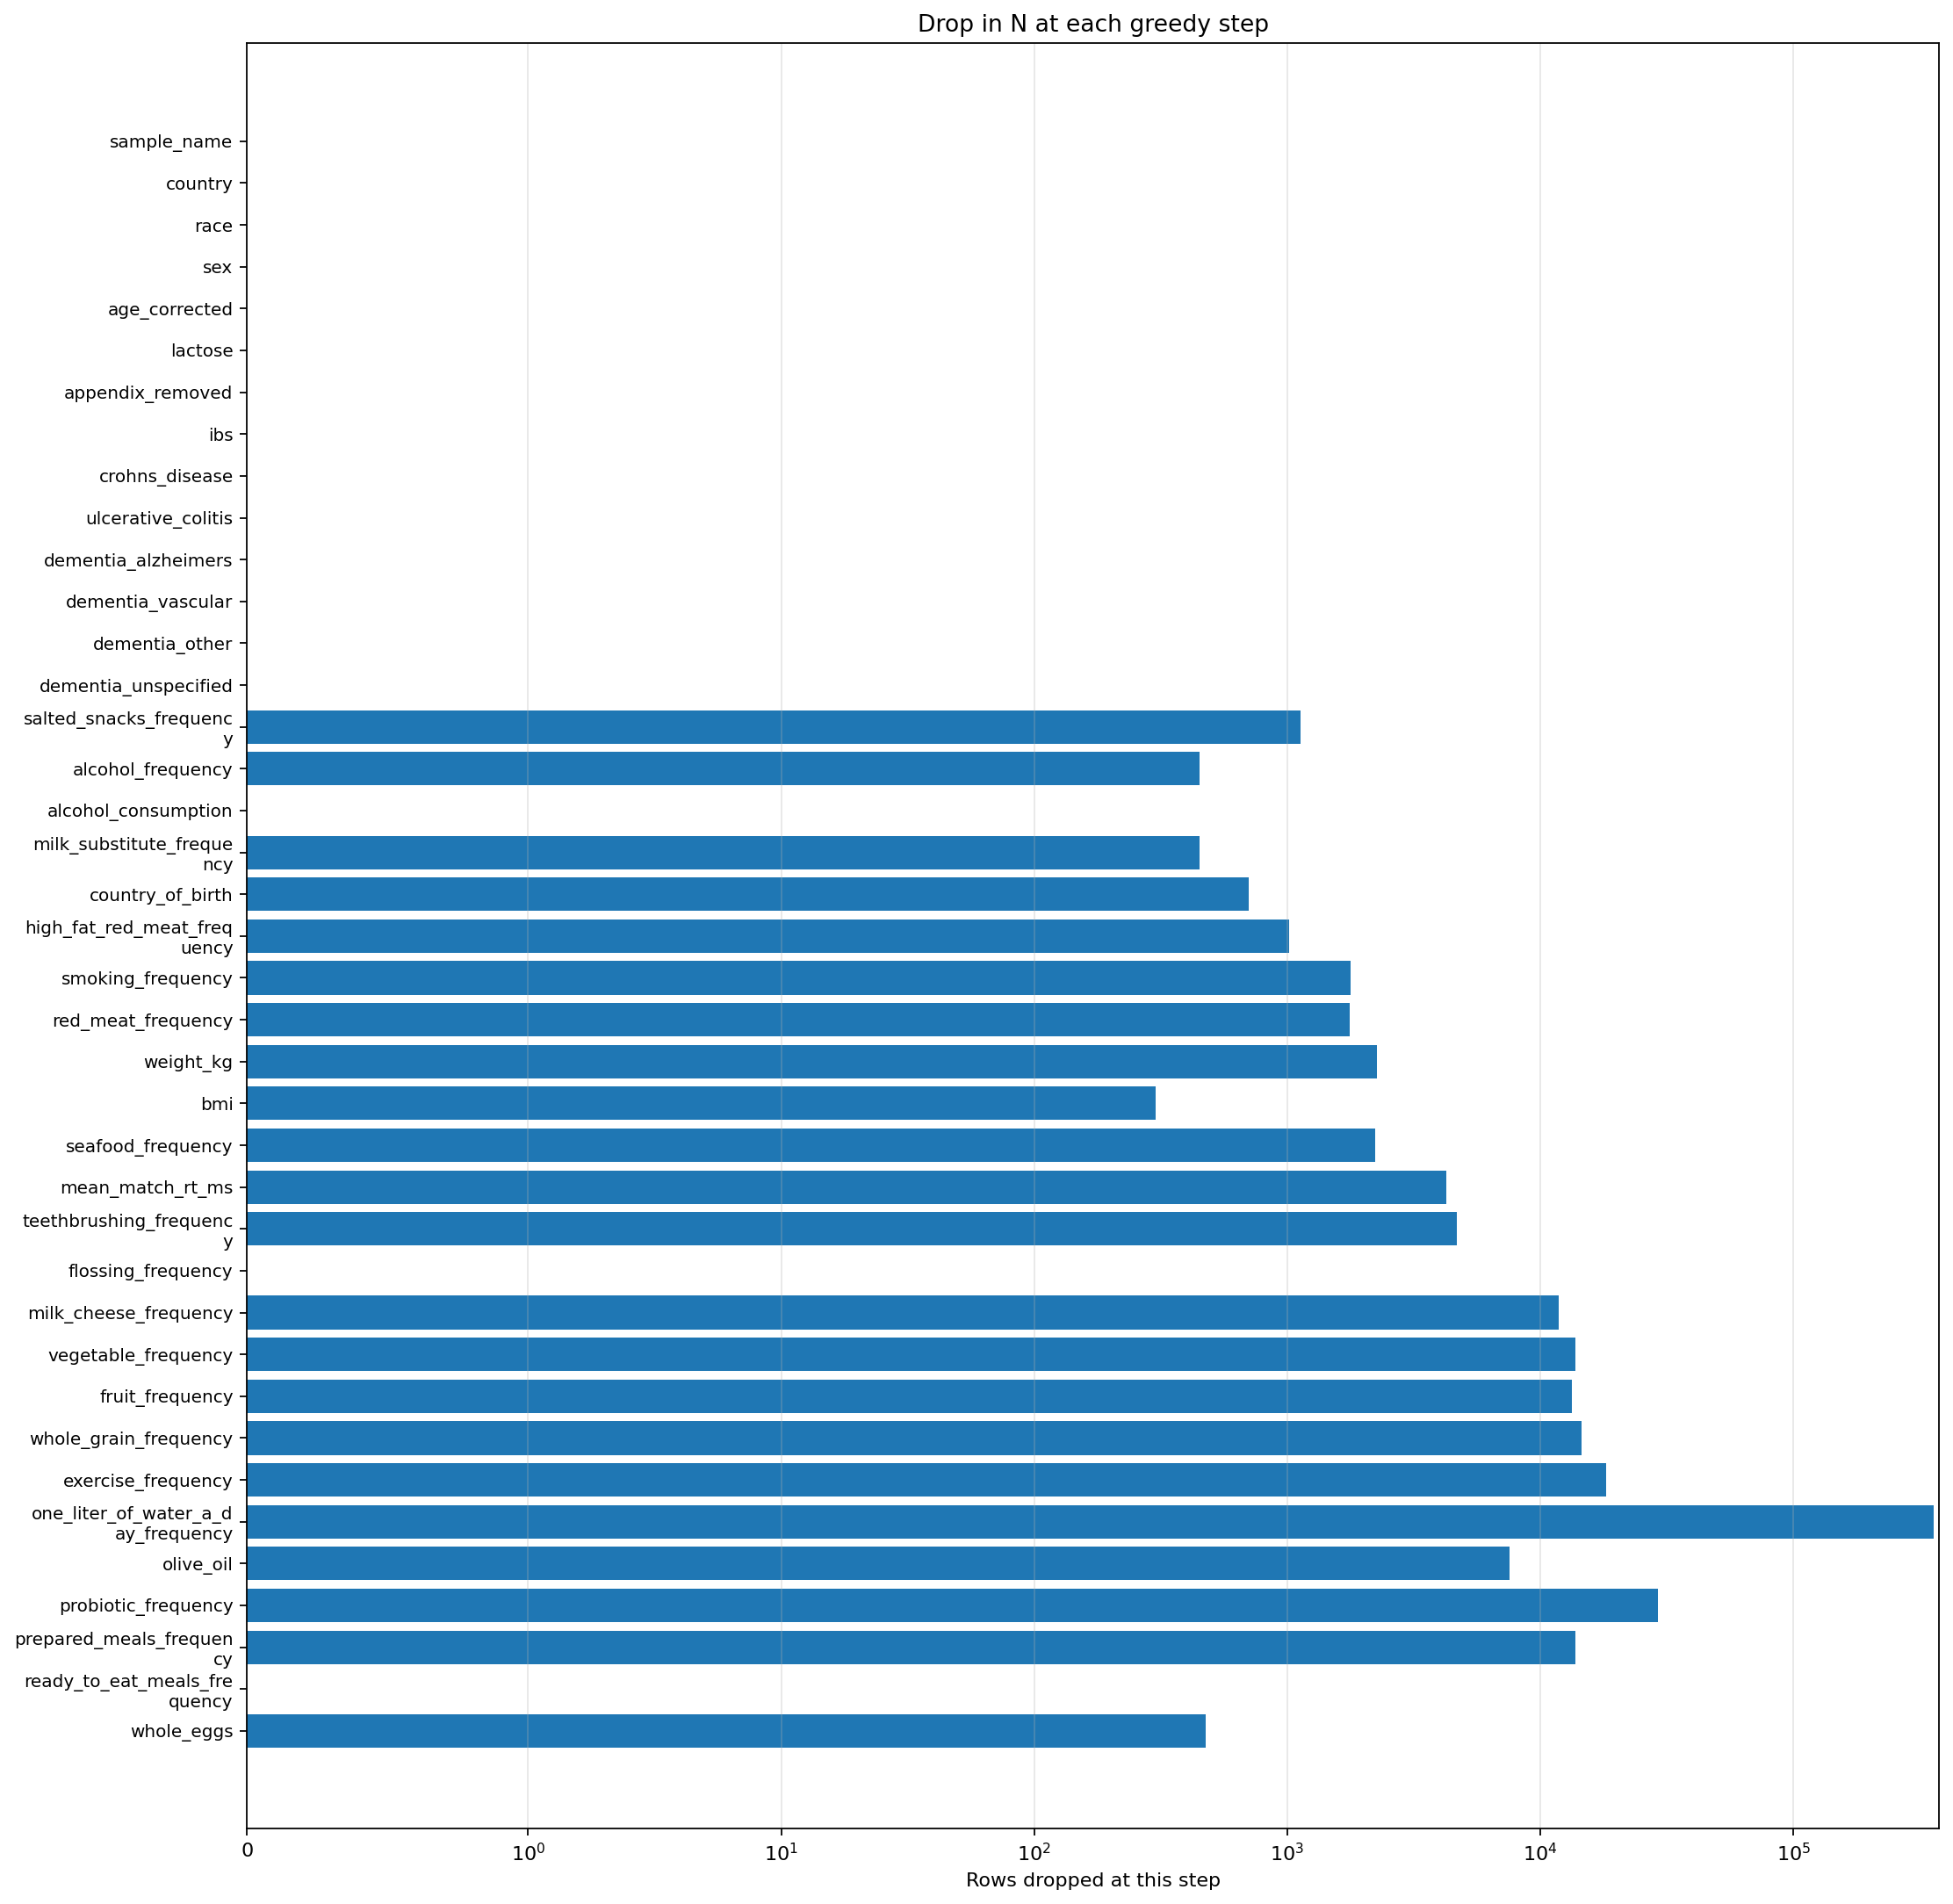

In [18]:
skip_cols = [
    "fluid_intelligence_score",
    "sugar_sweetened_drink_frequency",
    "free_sugar_scaled_0_5",
    "artificial_sweeteners",
]  # whatever you want to ignore entirely

res = greedy_complete_filter(df, id_cols=["eid"], skip_cols=skip_cols)
steps_df = res["steps"]
print(steps_df)
plot_attrition(steps_df)

    step                               field  n_before  n_after  dropped  \
0      1                         sample_name    502244   502244        0   
1      2                             country    502244   502244        0   
2      3                                race    502244   502244        0   
3      4                                 sex    502244   502244        0   
4      5                       age_corrected    502244   502244        0   
5      6                             lactose    502244   502244        0   
6      7                    appendix_removed    502244   502244        0   
7      8                                 ibs    502244   502244        0   
8      9                      crohns_disease    502244   502244        0   
9     10                  ulcerative_colitis    502244   502244        0   
10    11                 dementia_alzheimers    502244   502244        0   
11    12                   dementia_vascular    502244   502244        0   
12    13    

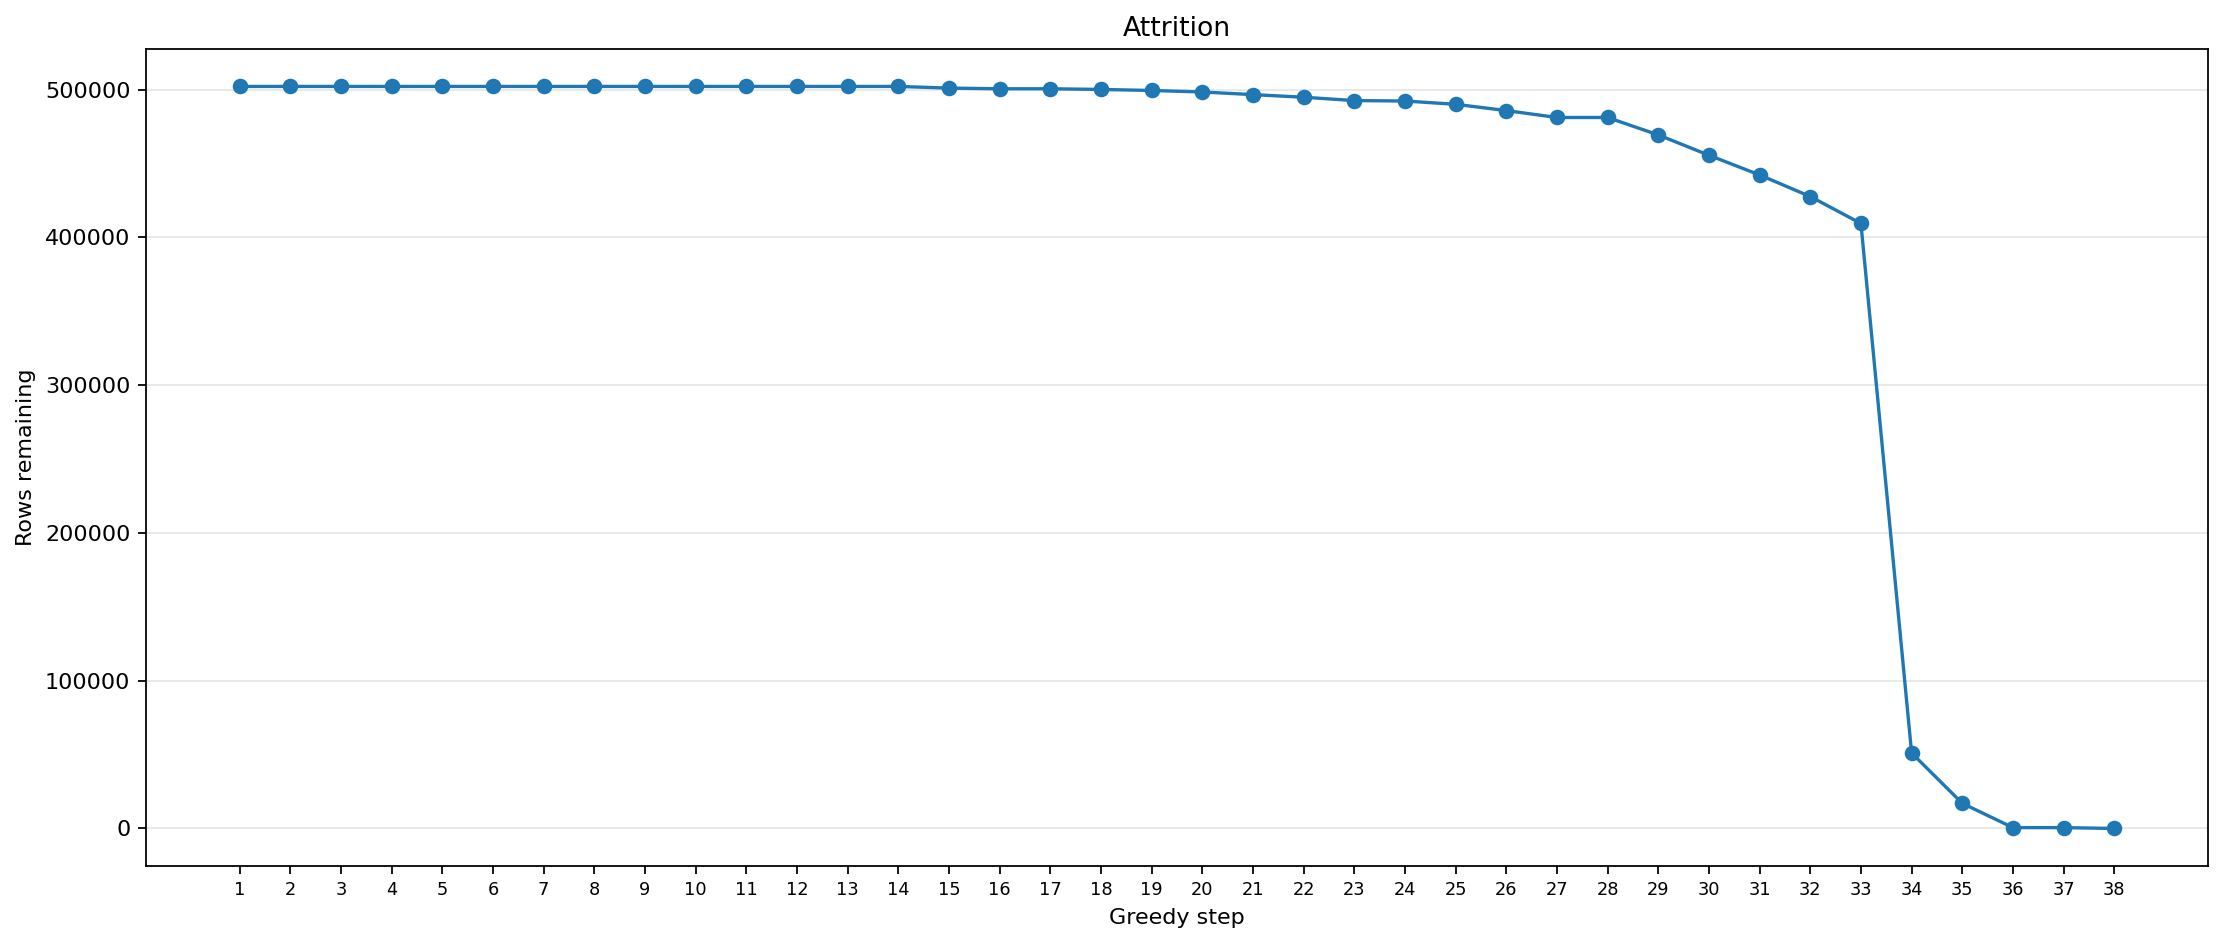

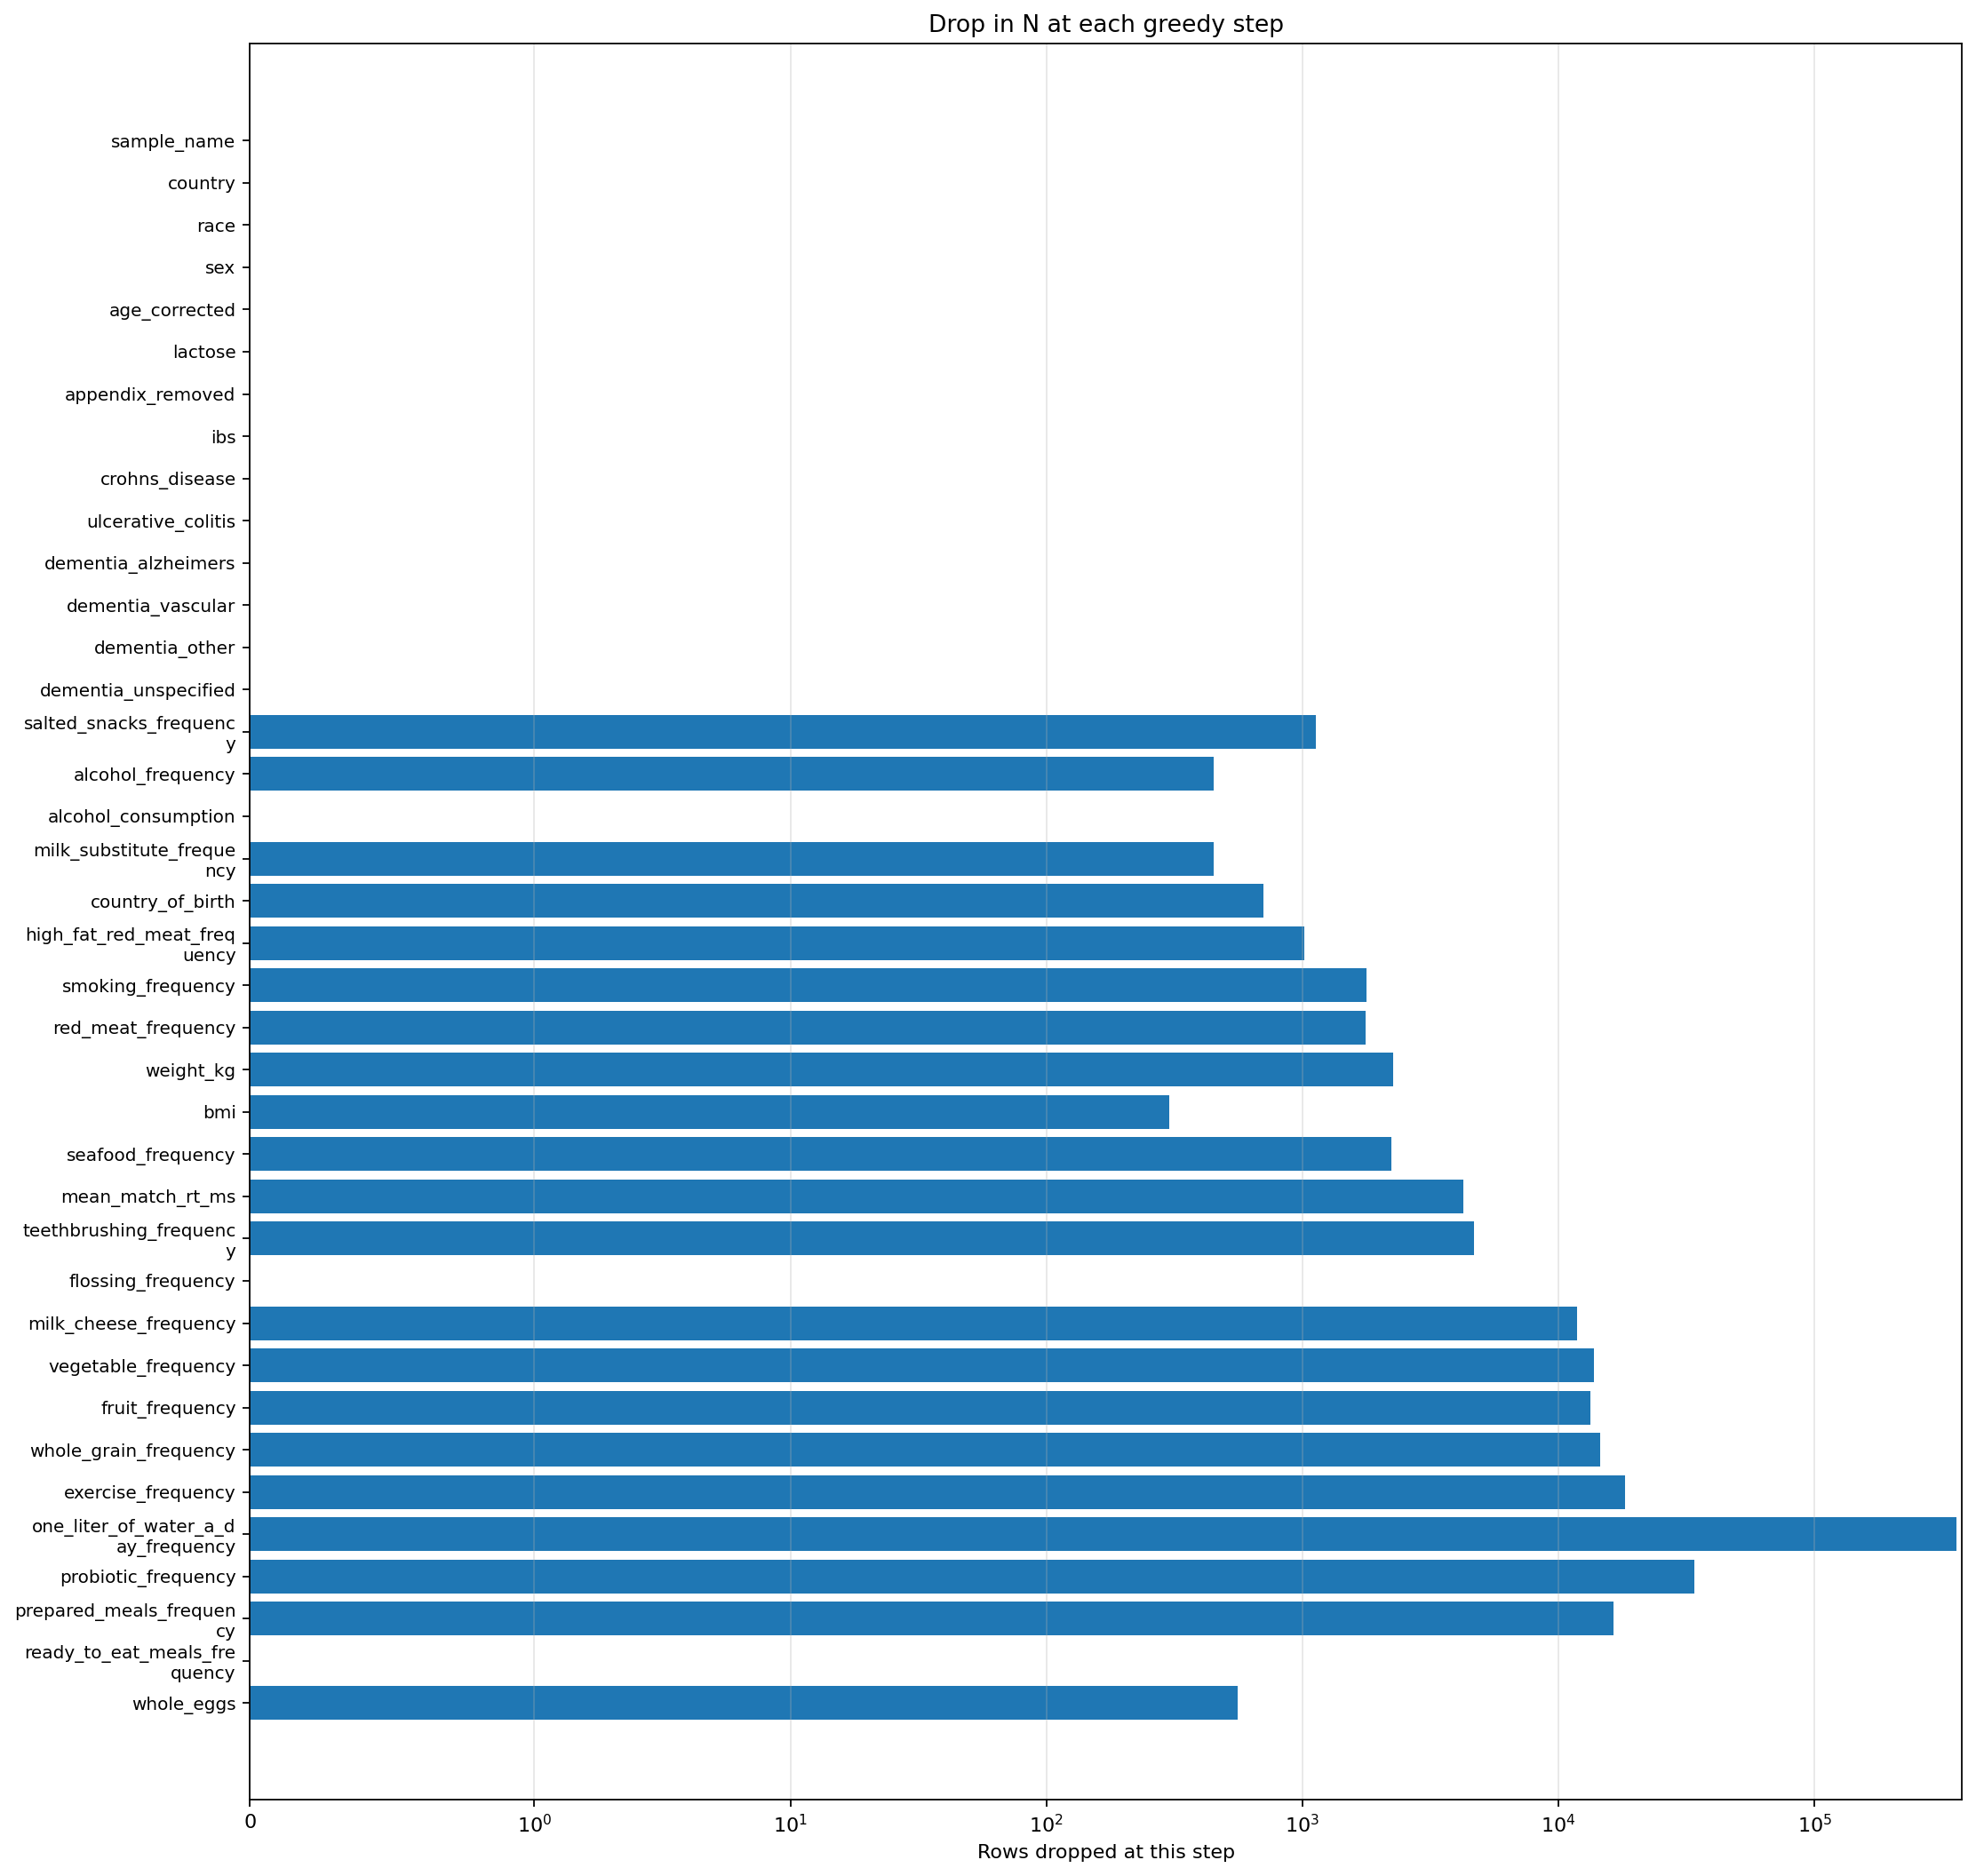

In [19]:
skip_cols = [
    "fluid_intelligence_score",
    "sugar_sweetened_drink_frequency",
    "free_sugar_scaled_0_5",
    "artificial_sweeteners",
    "olive_oil",
]  # whatever you want to ignore entirely

res = greedy_complete_filter(df, id_cols=["eid"], skip_cols=skip_cols)
steps_df = res["steps"]
print(steps_df)
plot_attrition(steps_df)

    step                         field  n_before  n_after  dropped  \
0      1                   sample_name    502244   502244        0   
1      2                       country    502244   502244        0   
2      3                          race    502244   502244        0   
3      4                           sex    502244   502244        0   
4      5                 age_corrected    502244   502244        0   
5      6                       lactose    502244   502244        0   
6      7              appendix_removed    502244   502244        0   
7      8                           ibs    502244   502244        0   
8      9                crohns_disease    502244   502244        0   
9     10            ulcerative_colitis    502244   502244        0   
10    11           dementia_alzheimers    502244   502244        0   
11    12             dementia_vascular    502244   502244        0   
12    13                dementia_other    502244   502244        0   
13    14          de

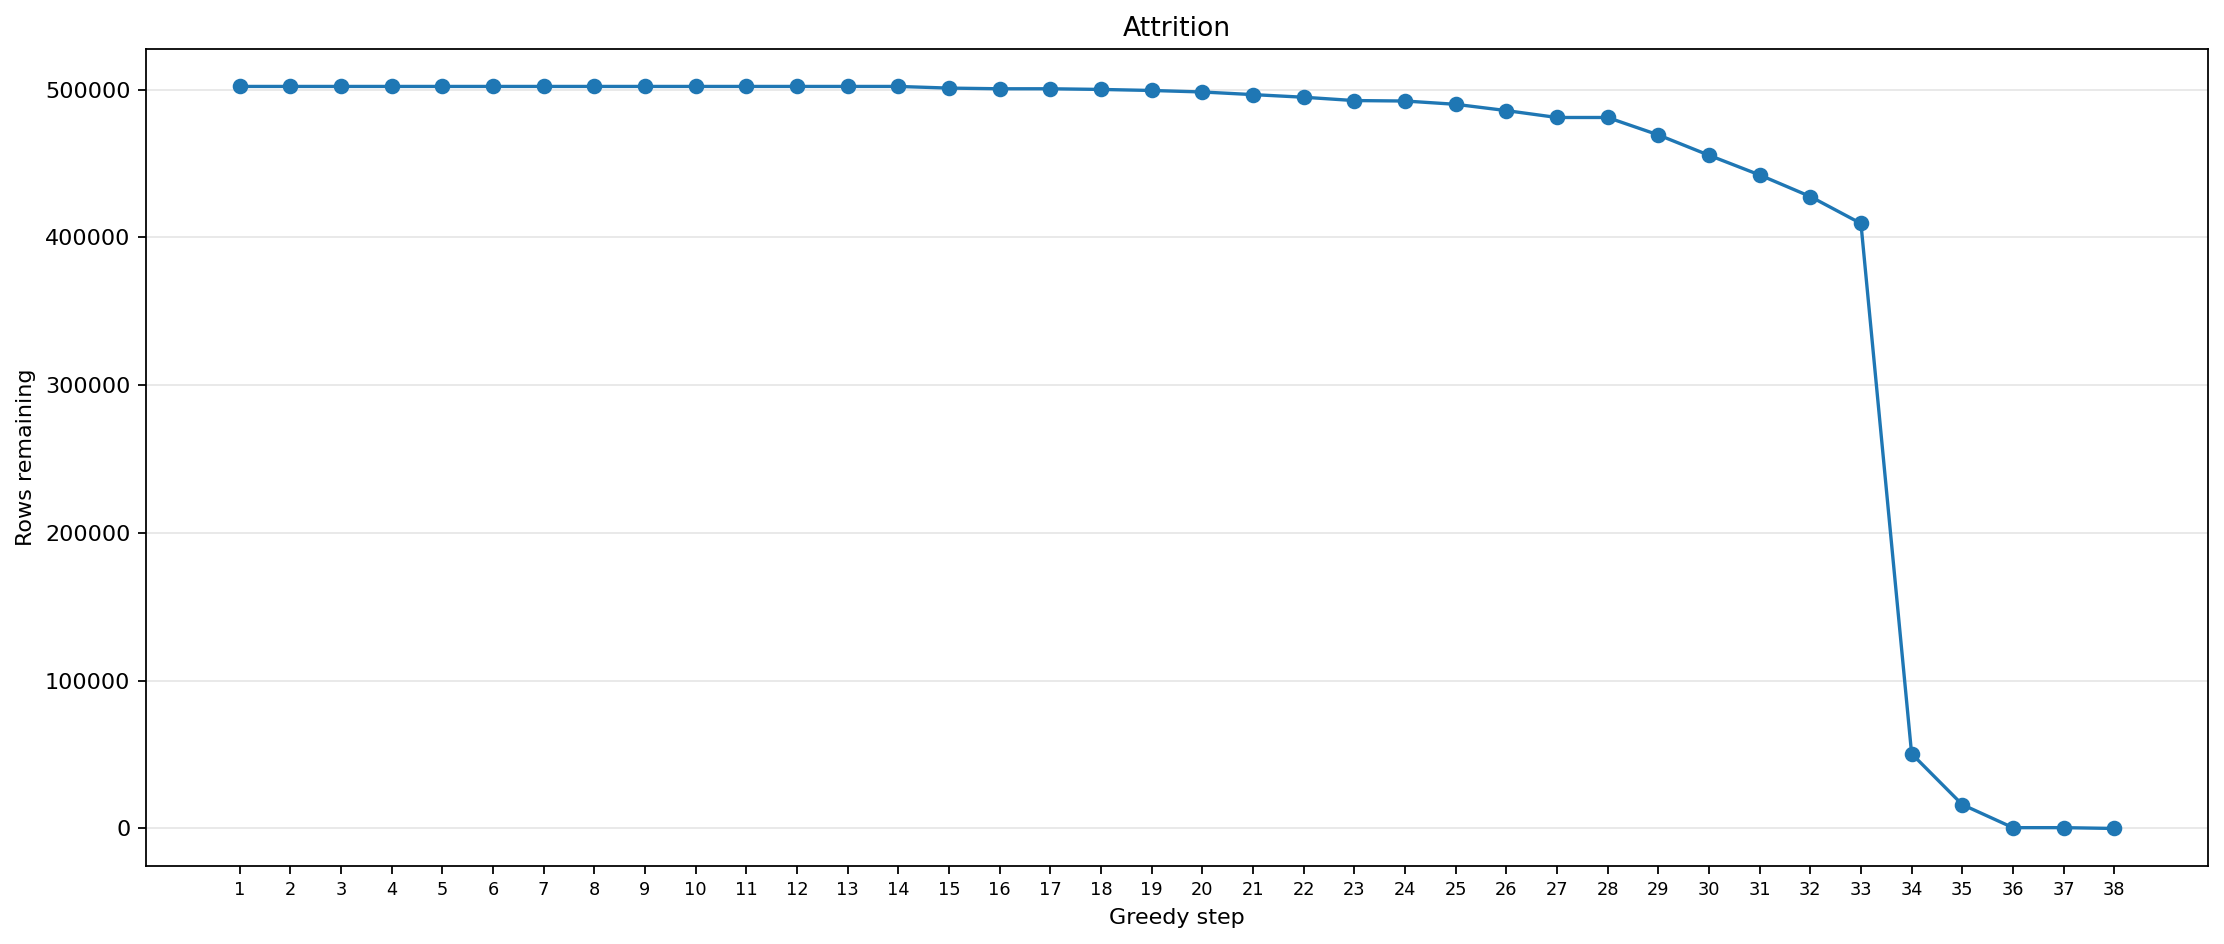

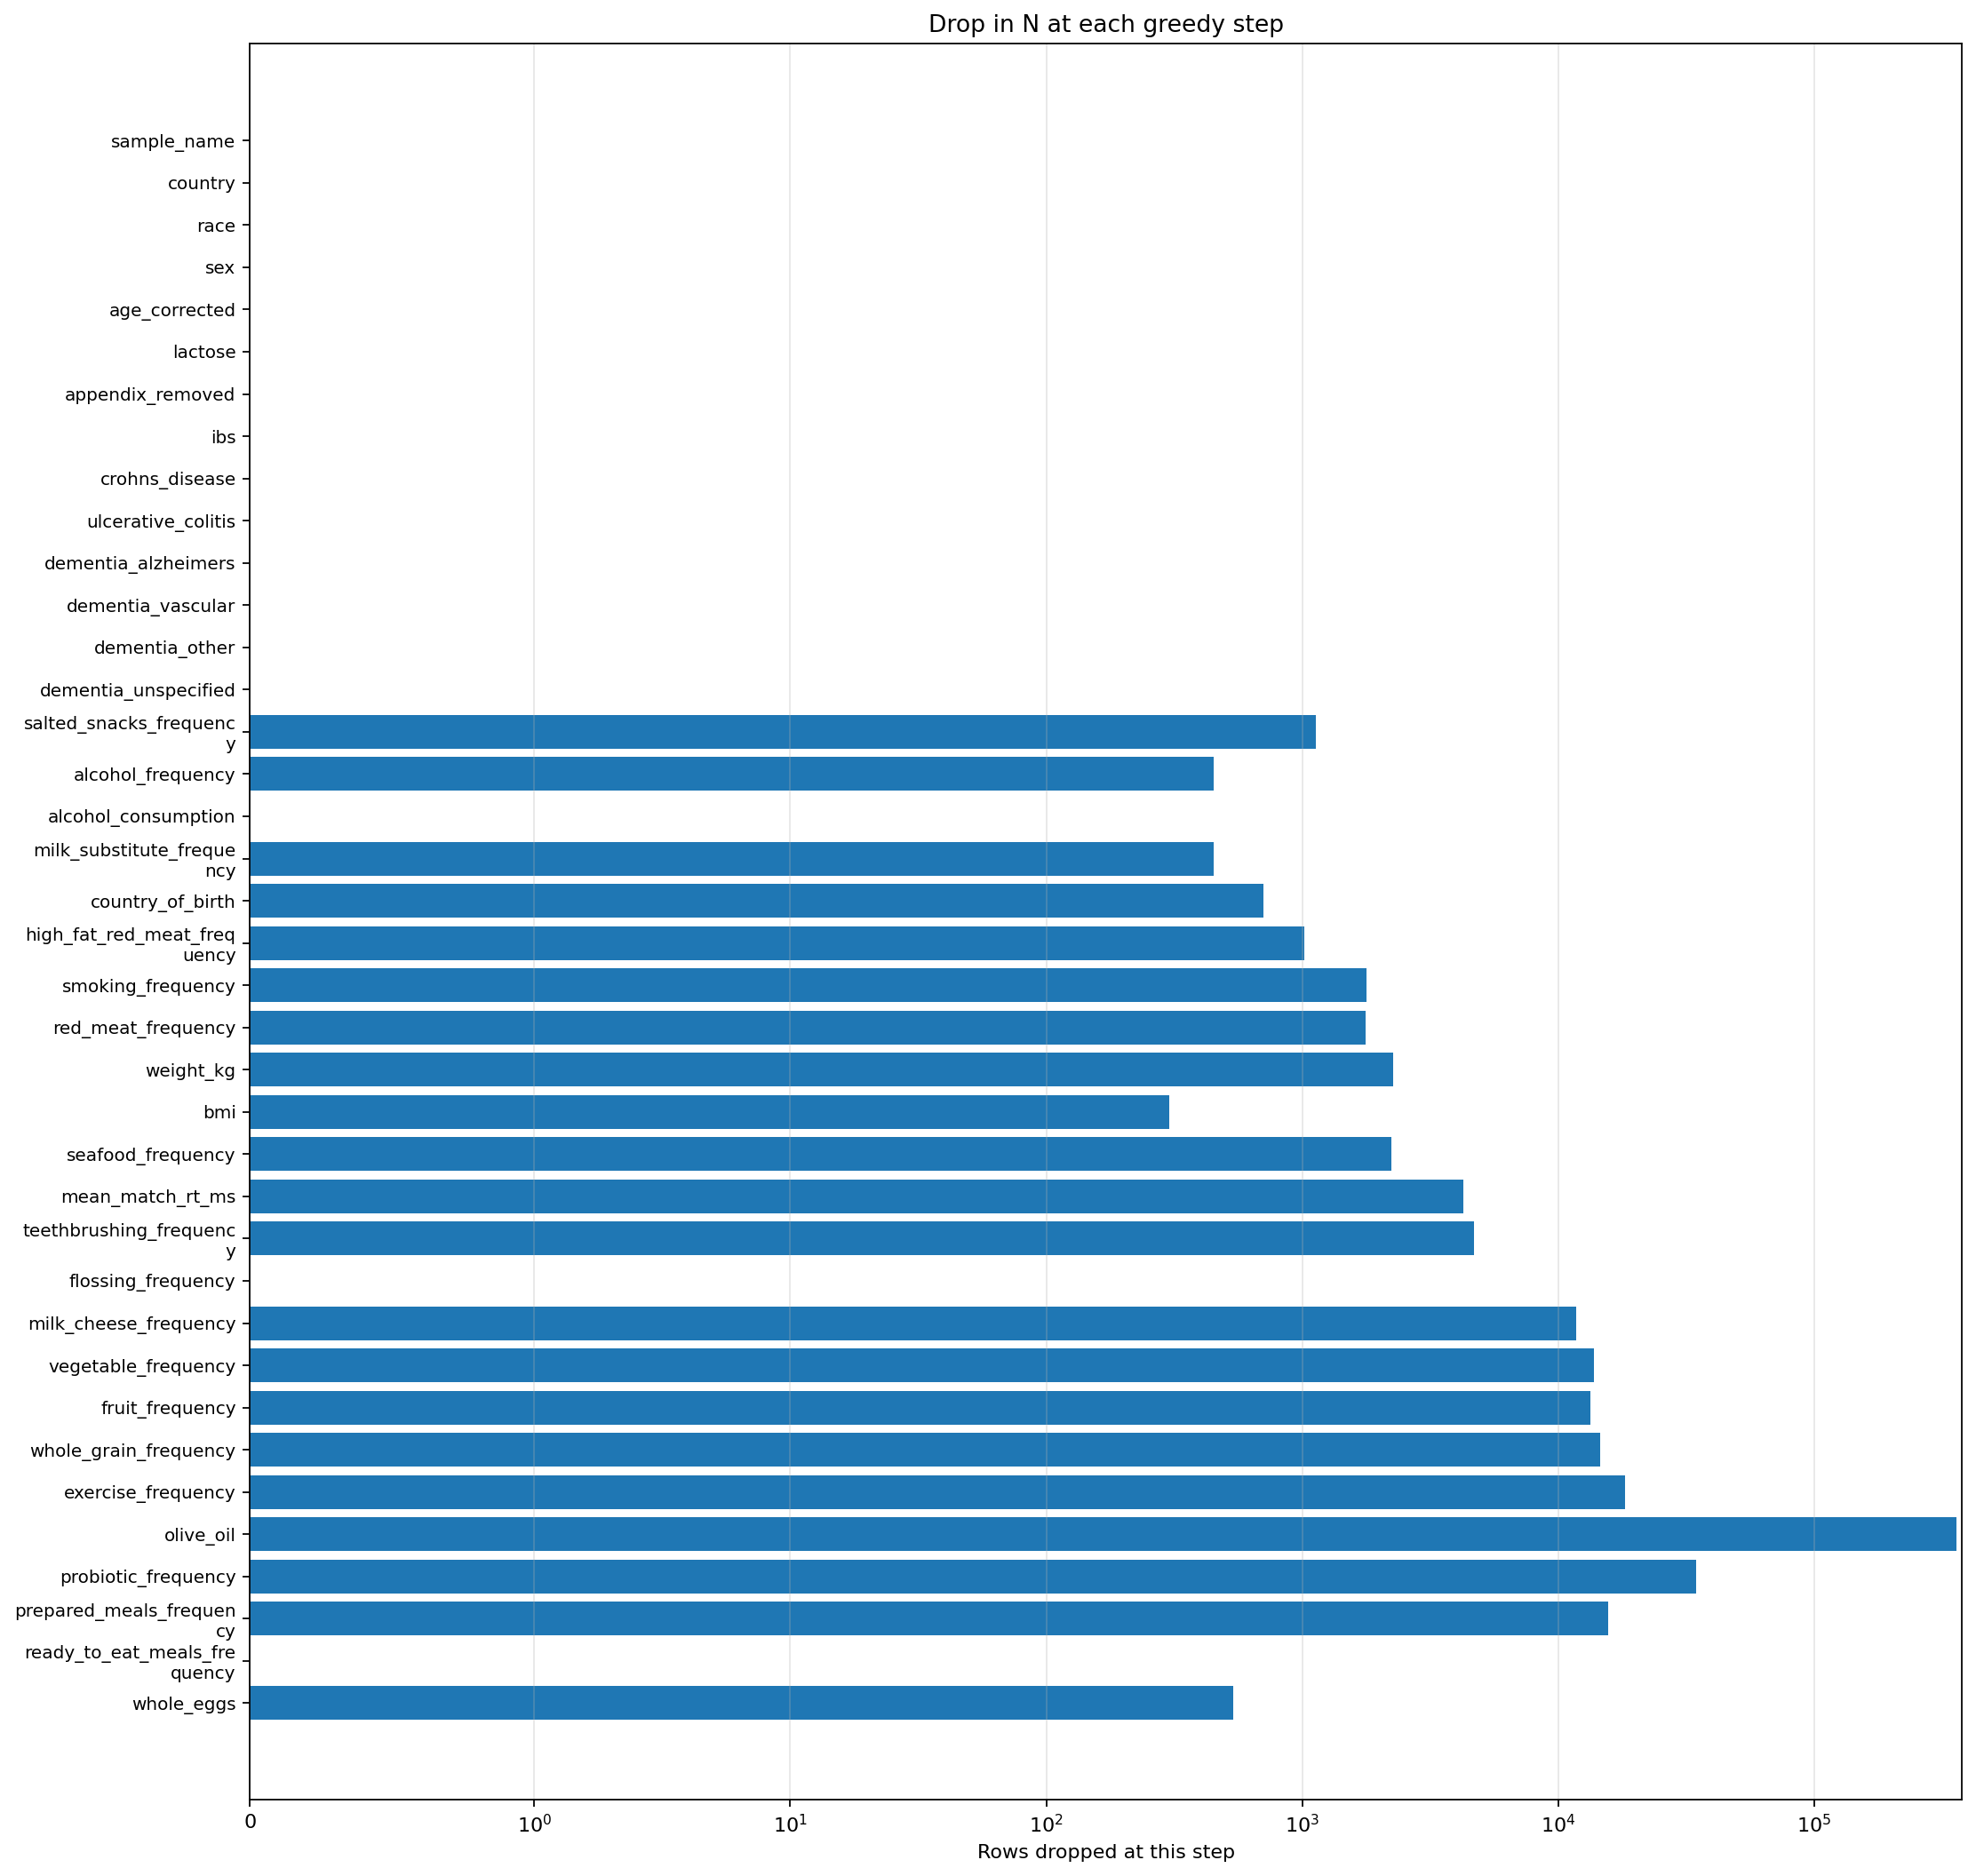

In [20]:
skip_cols = [
    "fluid_intelligence_score",
    "sugar_sweetened_drink_frequency",
    "free_sugar_scaled_0_5",
    "artificial_sweeteners",
    "one_liter_of_water_a_day_frequency",
]  # whatever you want to ignore entirely

res = greedy_complete_filter(df, id_cols=["eid"], skip_cols=skip_cols)
steps_df = res["steps"]
print(steps_df)
plot_attrition(steps_df)

    step                         field  n_before  n_after  dropped  \
0      1                   sample_name    502244   502244        0   
1      2                       country    502244   502244        0   
2      3                          race    502244   502244        0   
3      4                           sex    502244   502244        0   
4      5                 age_corrected    502244   502244        0   
5      6                       lactose    502244   502244        0   
6      7              appendix_removed    502244   502244        0   
7      8                           ibs    502244   502244        0   
8      9                crohns_disease    502244   502244        0   
9     10            ulcerative_colitis    502244   502244        0   
10    11           dementia_alzheimers    502244   502244        0   
11    12             dementia_vascular    502244   502244        0   
12    13                dementia_other    502244   502244        0   
13    14          de

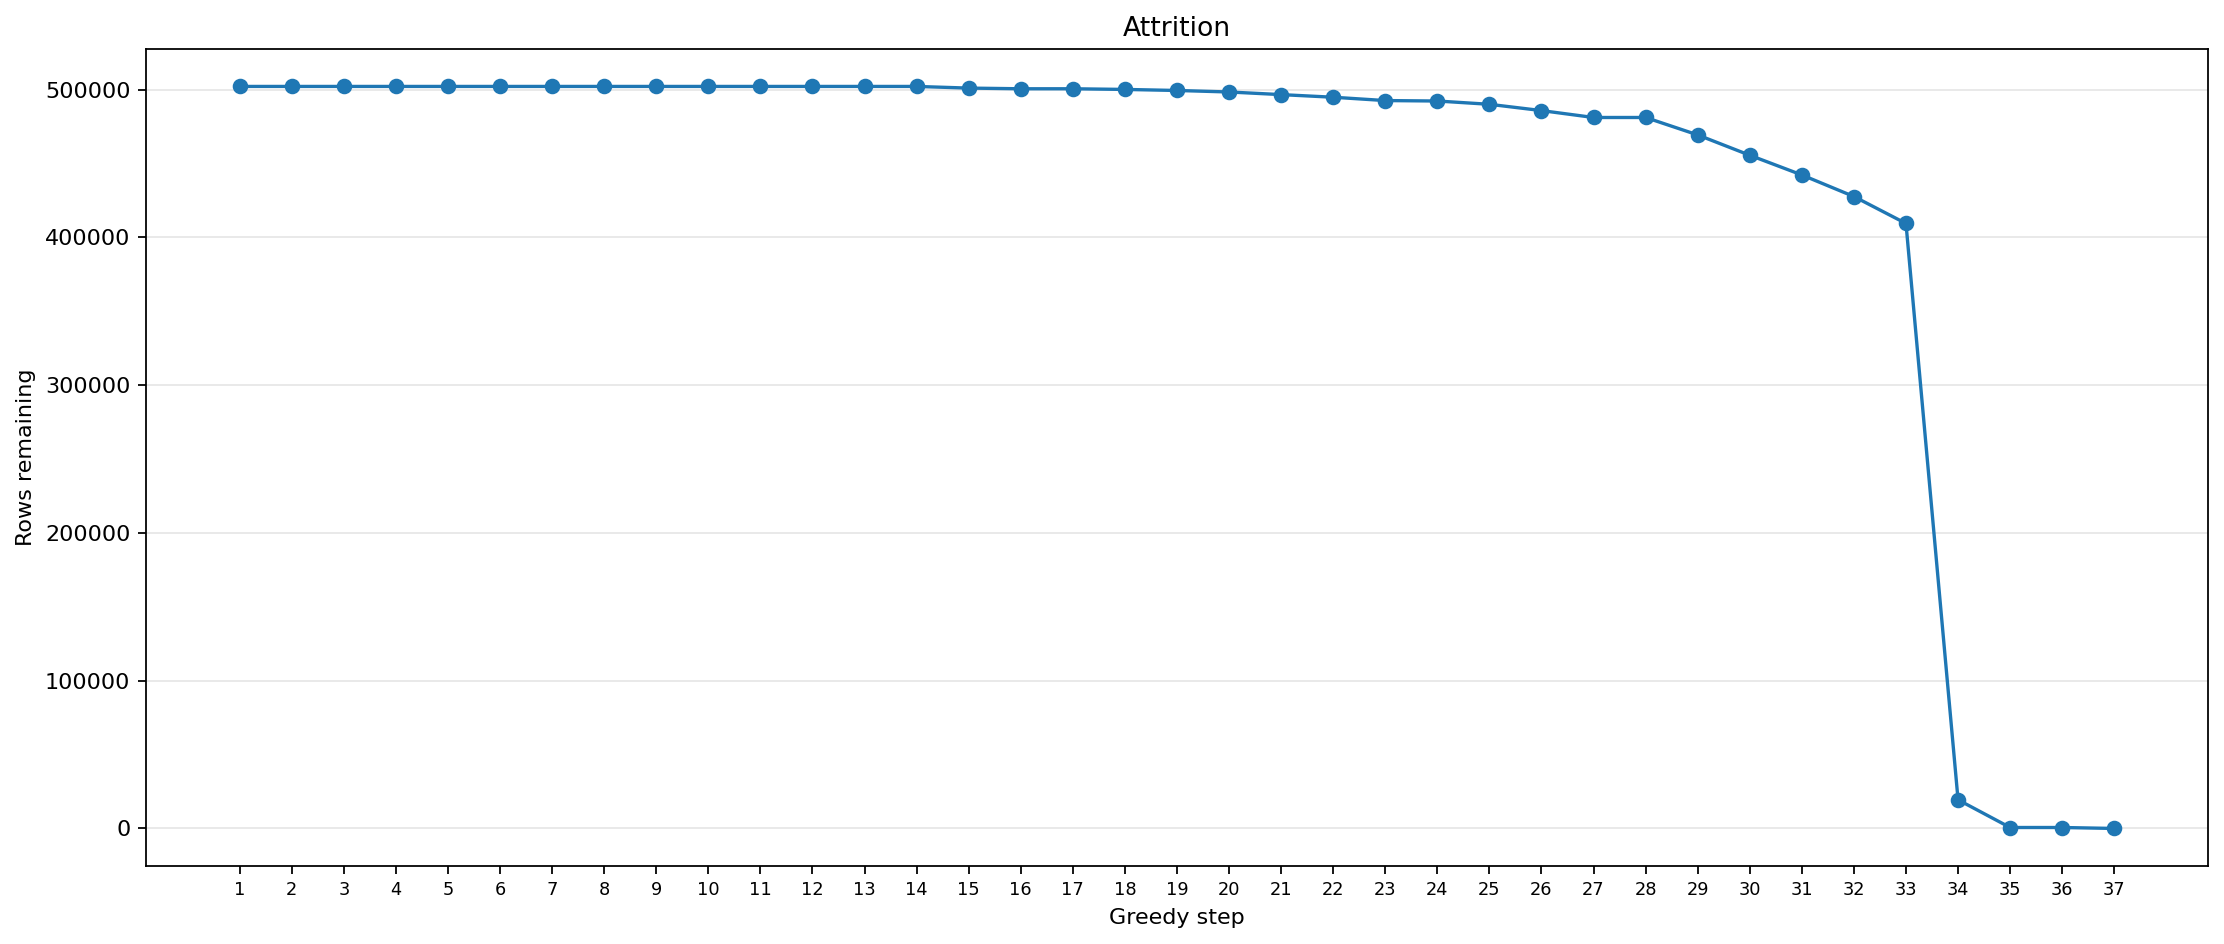

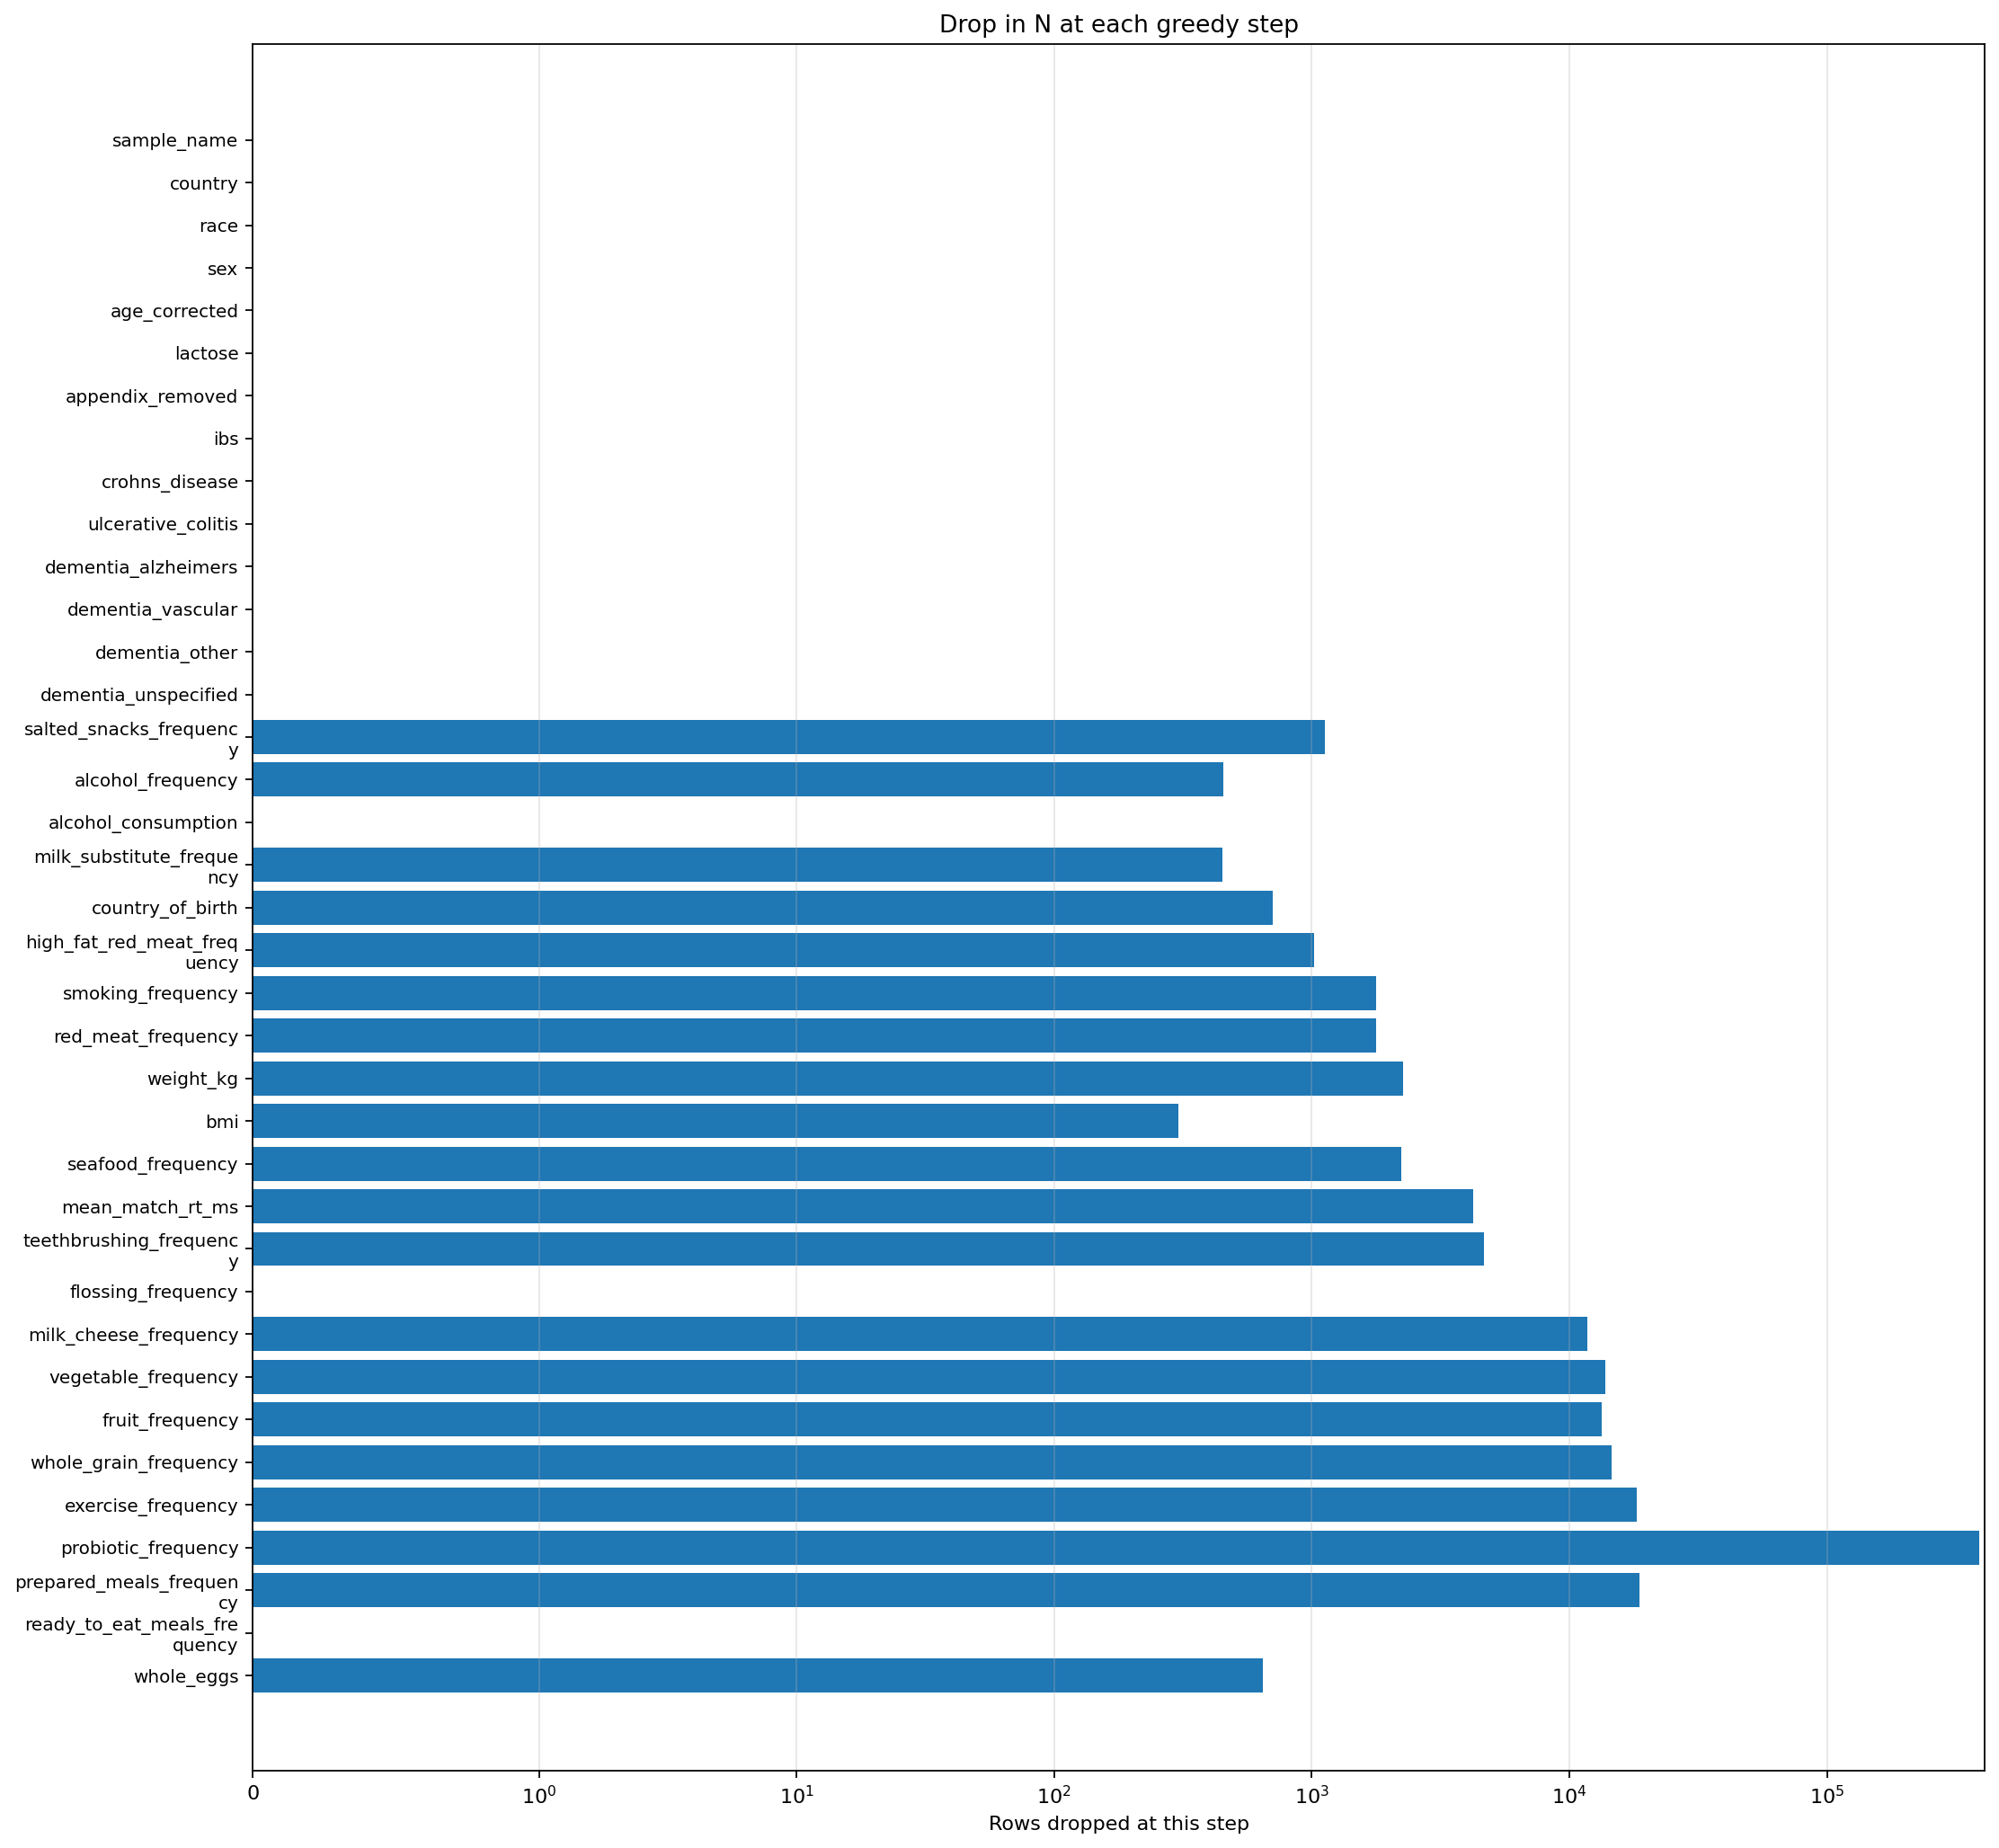

In [22]:
skip_cols = [
    "fluid_intelligence_score",
    "sugar_sweetened_drink_frequency",
    "free_sugar_scaled_0_5",
    "artificial_sweeteners",
    "one_liter_of_water_a_day_frequency",
    "olive_oil",
]  # whatever you want to ignore entirely

res = greedy_complete_filter(df, id_cols=["eid"], skip_cols=skip_cols)
steps_df = res["steps"]
print(steps_df)
plot_attrition(steps_df)

    step                        field  n_before  n_after  dropped  \
0      1                  sample_name    502244   502244        0   
1      2                      country    502244   502244        0   
2      3                         race    502244   502244        0   
3      4                          sex    502244   502244        0   
4      5                age_corrected    502244   502244        0   
5      6                      lactose    502244   502244        0   
6      7             appendix_removed    502244   502244        0   
7      8                          ibs    502244   502244        0   
8      9               crohns_disease    502244   502244        0   
9     10           ulcerative_colitis    502244   502244        0   
10    11          dementia_alzheimers    502244   502244        0   
11    12            dementia_vascular    502244   502244        0   
12    13               dementia_other    502244   502244        0   
13    14         dementia_unspecif

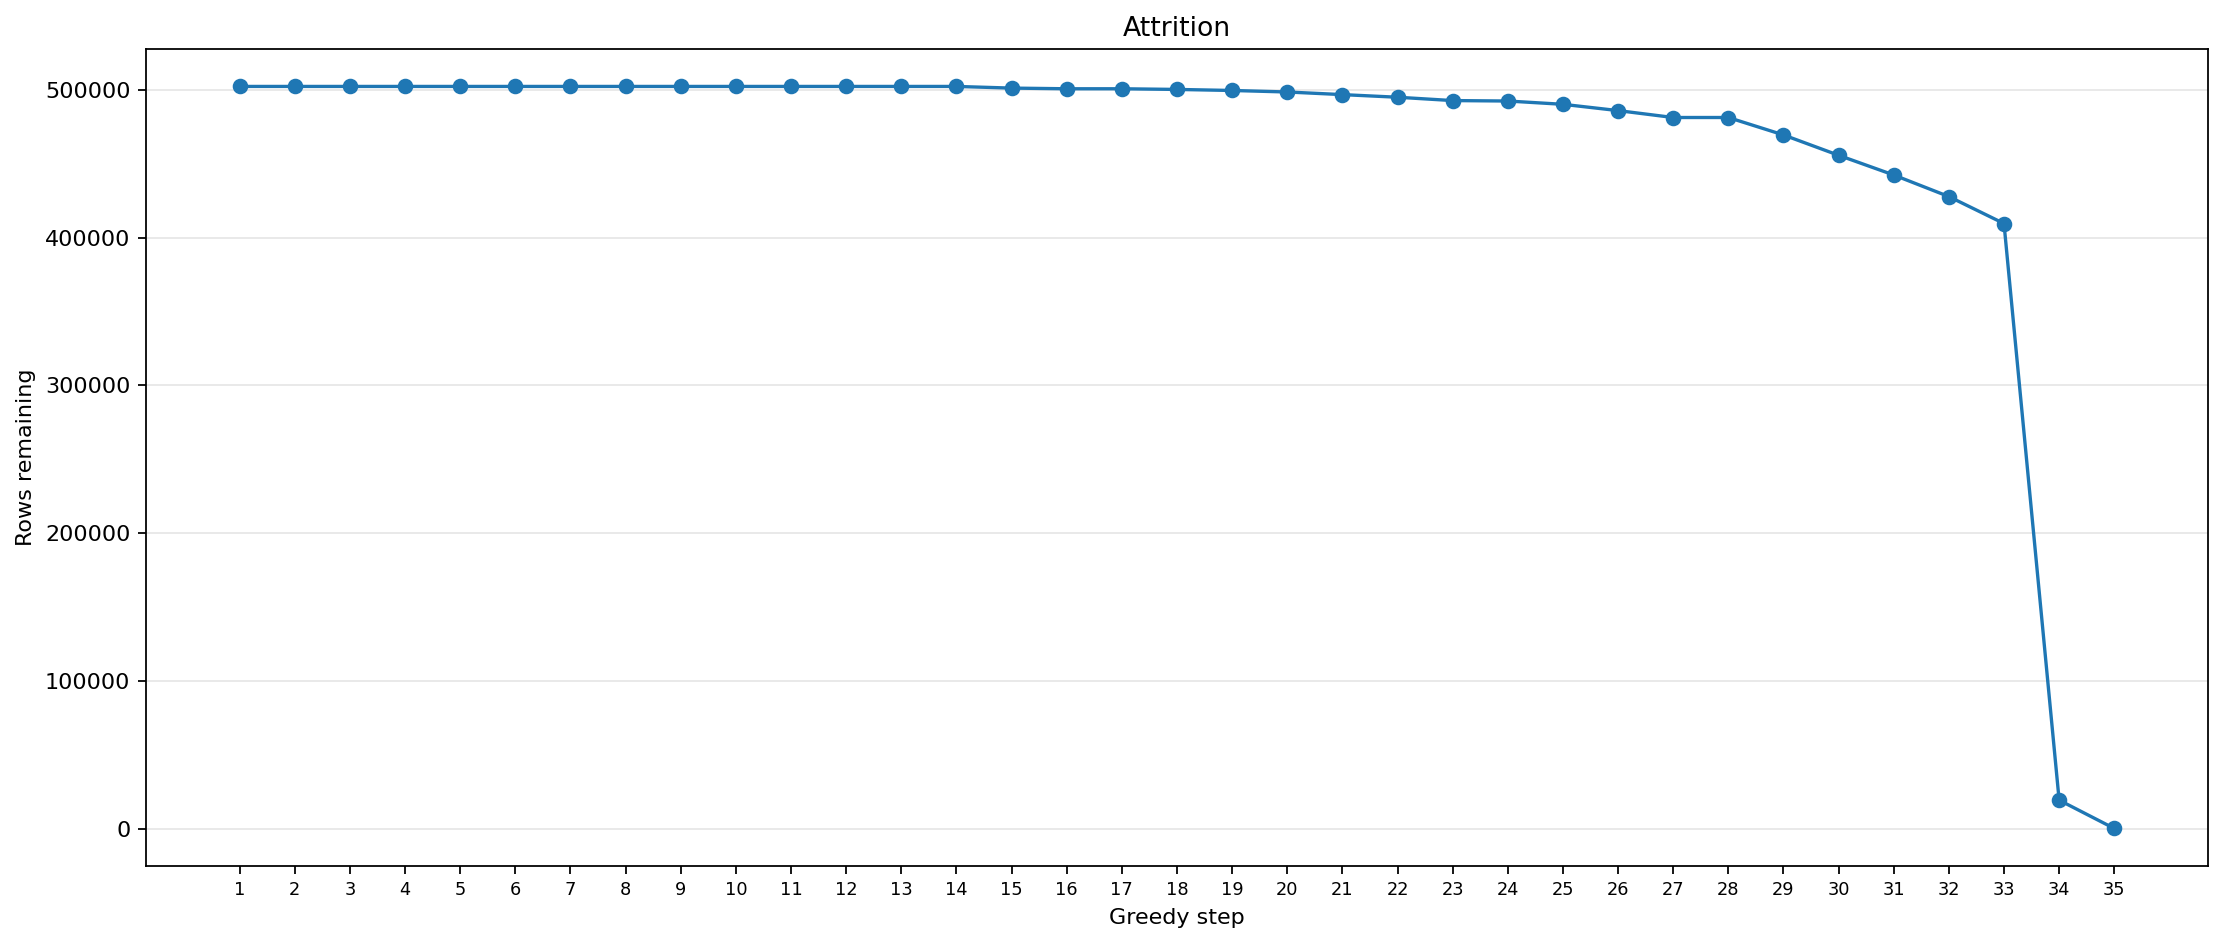

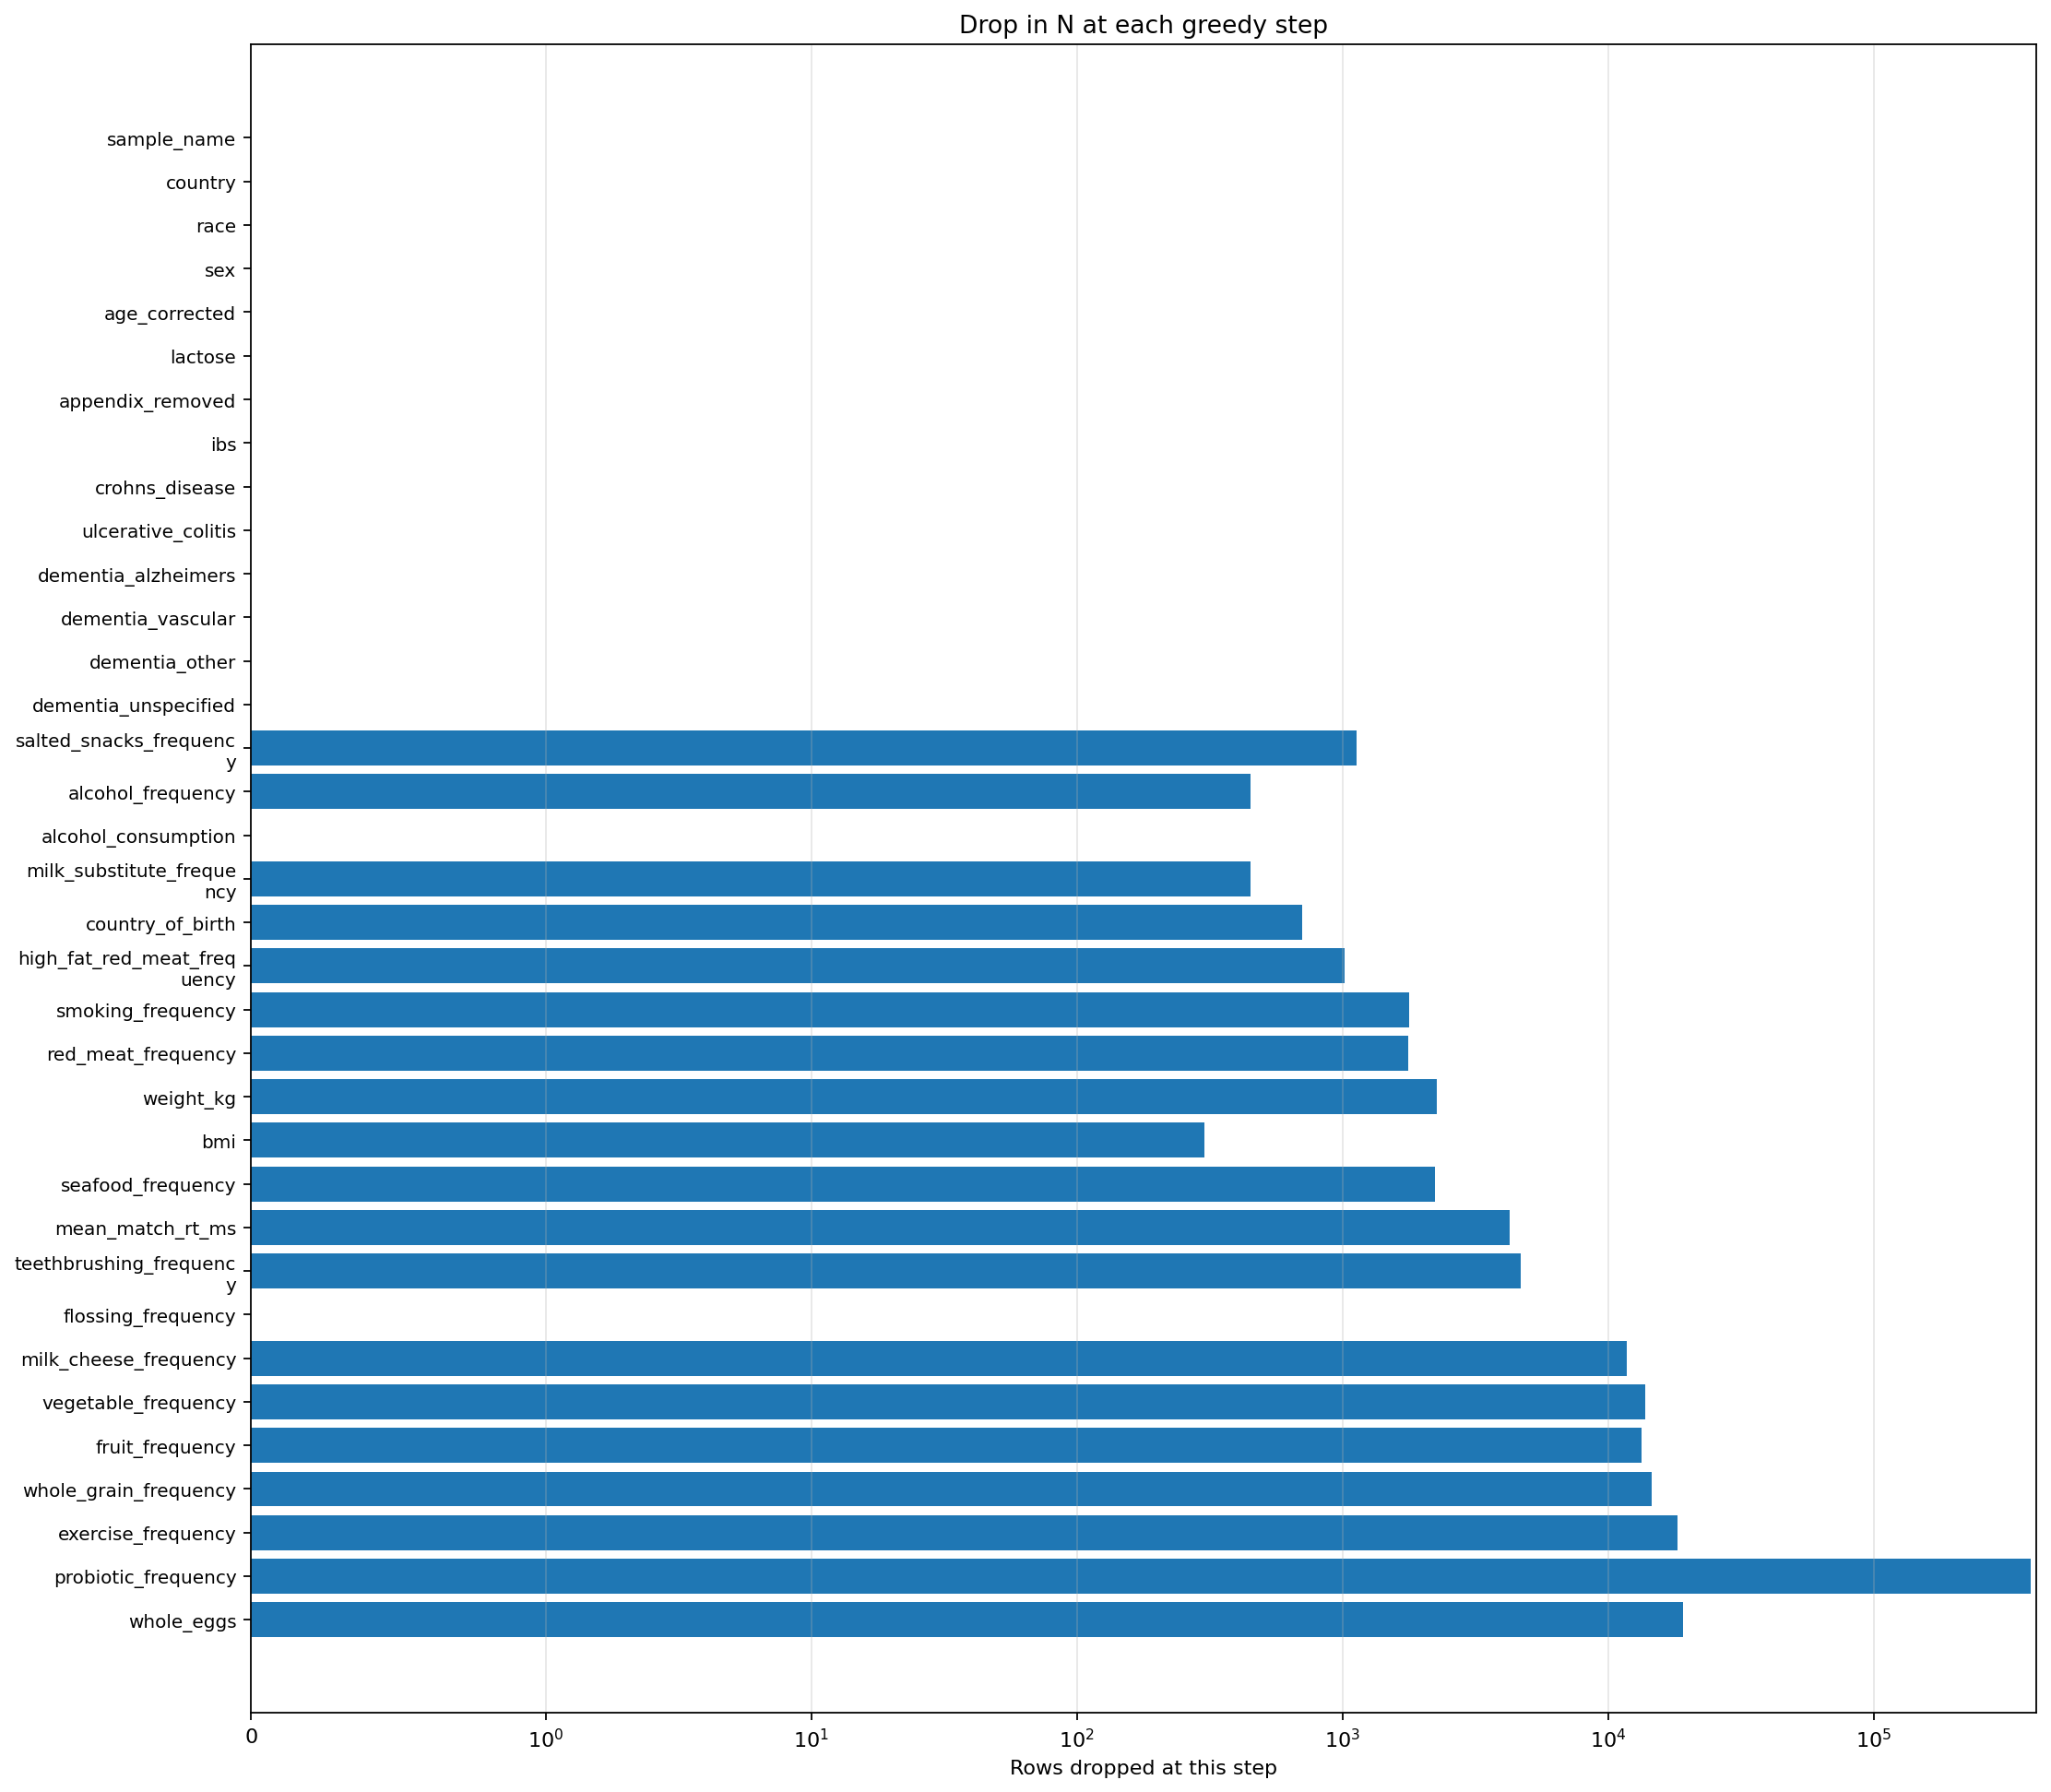

In [23]:
skip_cols = [
    "fluid_intelligence_score",
    "sugar_sweetened_drink_frequency",
    "free_sugar_scaled_0_5",
    "artificial_sweeteners",
    "one_liter_of_water_a_day_frequency",
    "olive_oil",
    "prepared_meals_frequency",
    "ready_to_eat_meals_frequency",
]  # whatever you want to ignore entirely

res = greedy_complete_filter(df, id_cols=["eid"], skip_cols=skip_cols)
steps_df = res["steps"]
print(steps_df)
plot_attrition(steps_df)

    step                        field  n_before  n_after  dropped  \
0      1                  sample_name    502244   502244        0   
1      2                      country    502244   502244        0   
2      3                         race    502244   502244        0   
3      4                          sex    502244   502244        0   
4      5                age_corrected    502244   502244        0   
5      6                      lactose    502244   502244        0   
6      7             appendix_removed    502244   502244        0   
7      8                          ibs    502244   502244        0   
8      9               crohns_disease    502244   502244        0   
9     10           ulcerative_colitis    502244   502244        0   
10    11          dementia_alzheimers    502244   502244        0   
11    12            dementia_vascular    502244   502244        0   
12    13               dementia_other    502244   502244        0   
13    14         dementia_unspecif

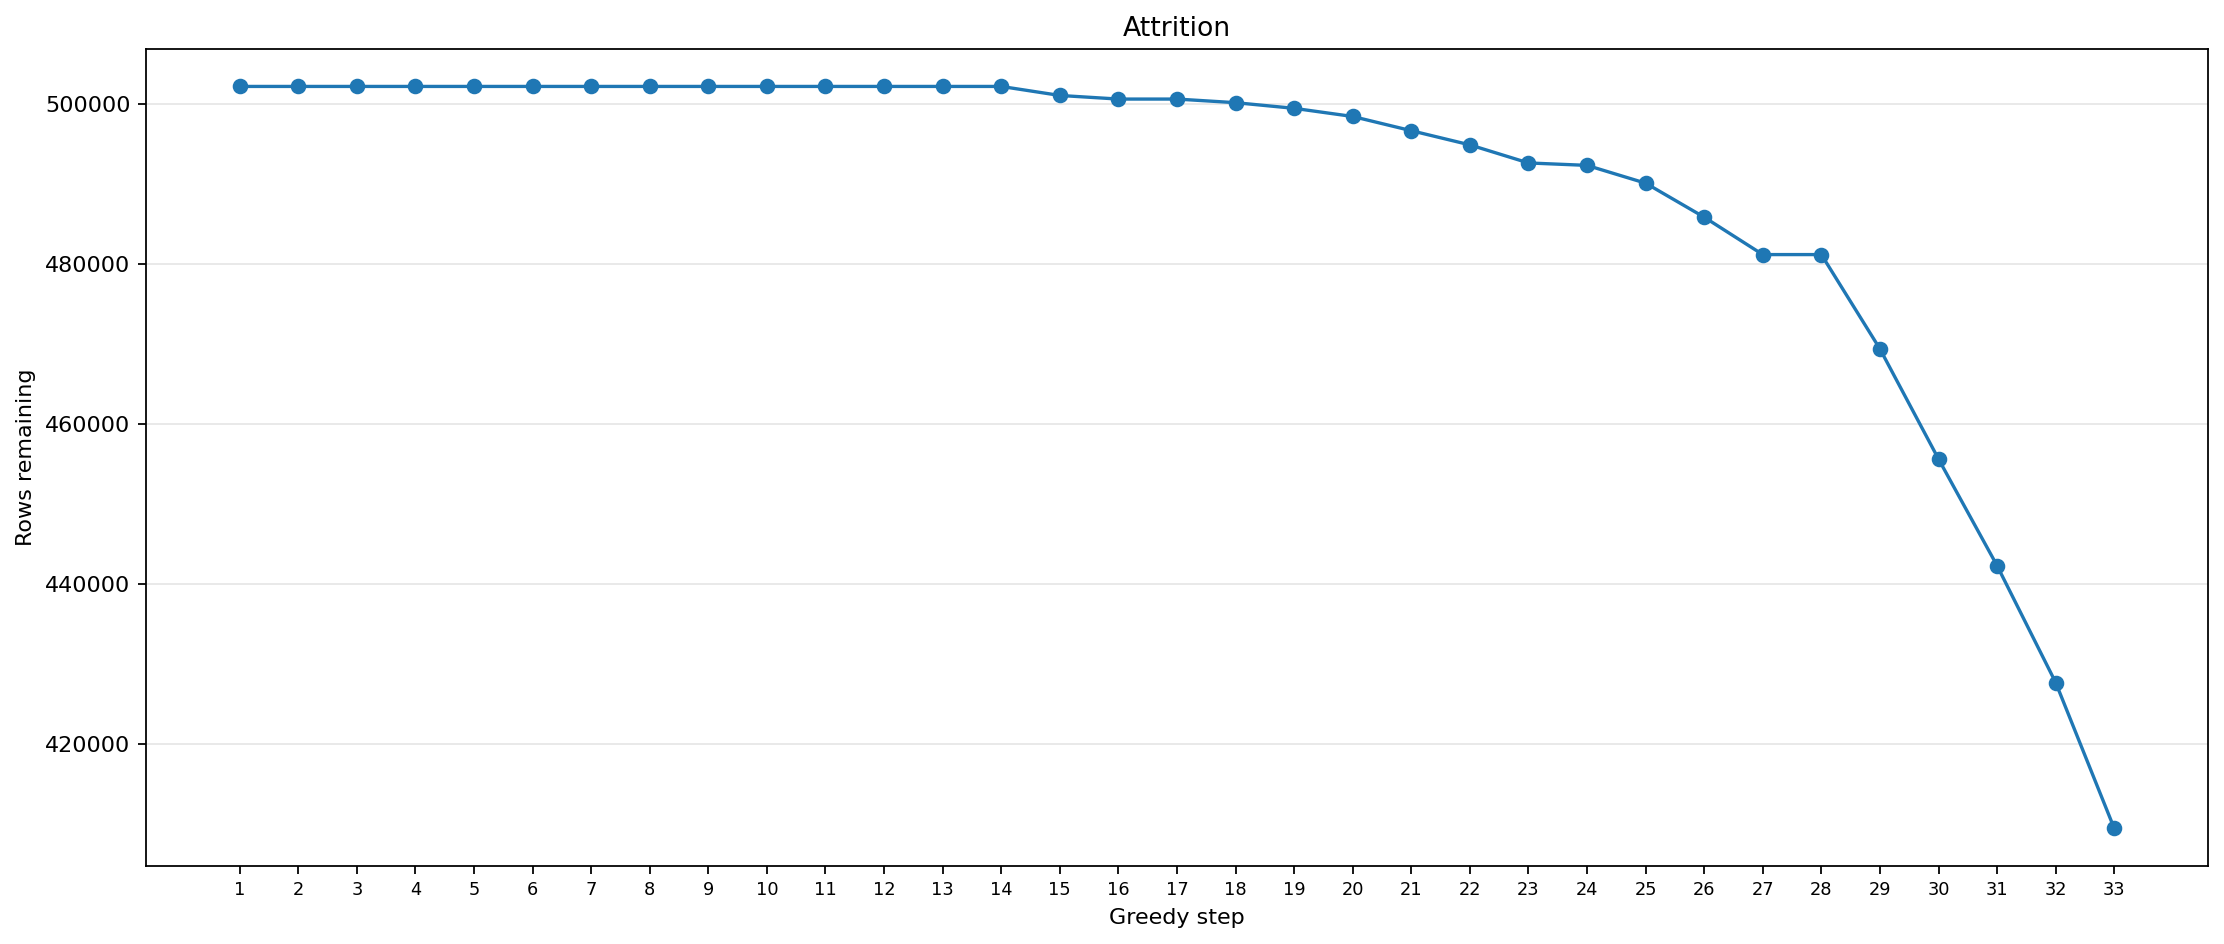

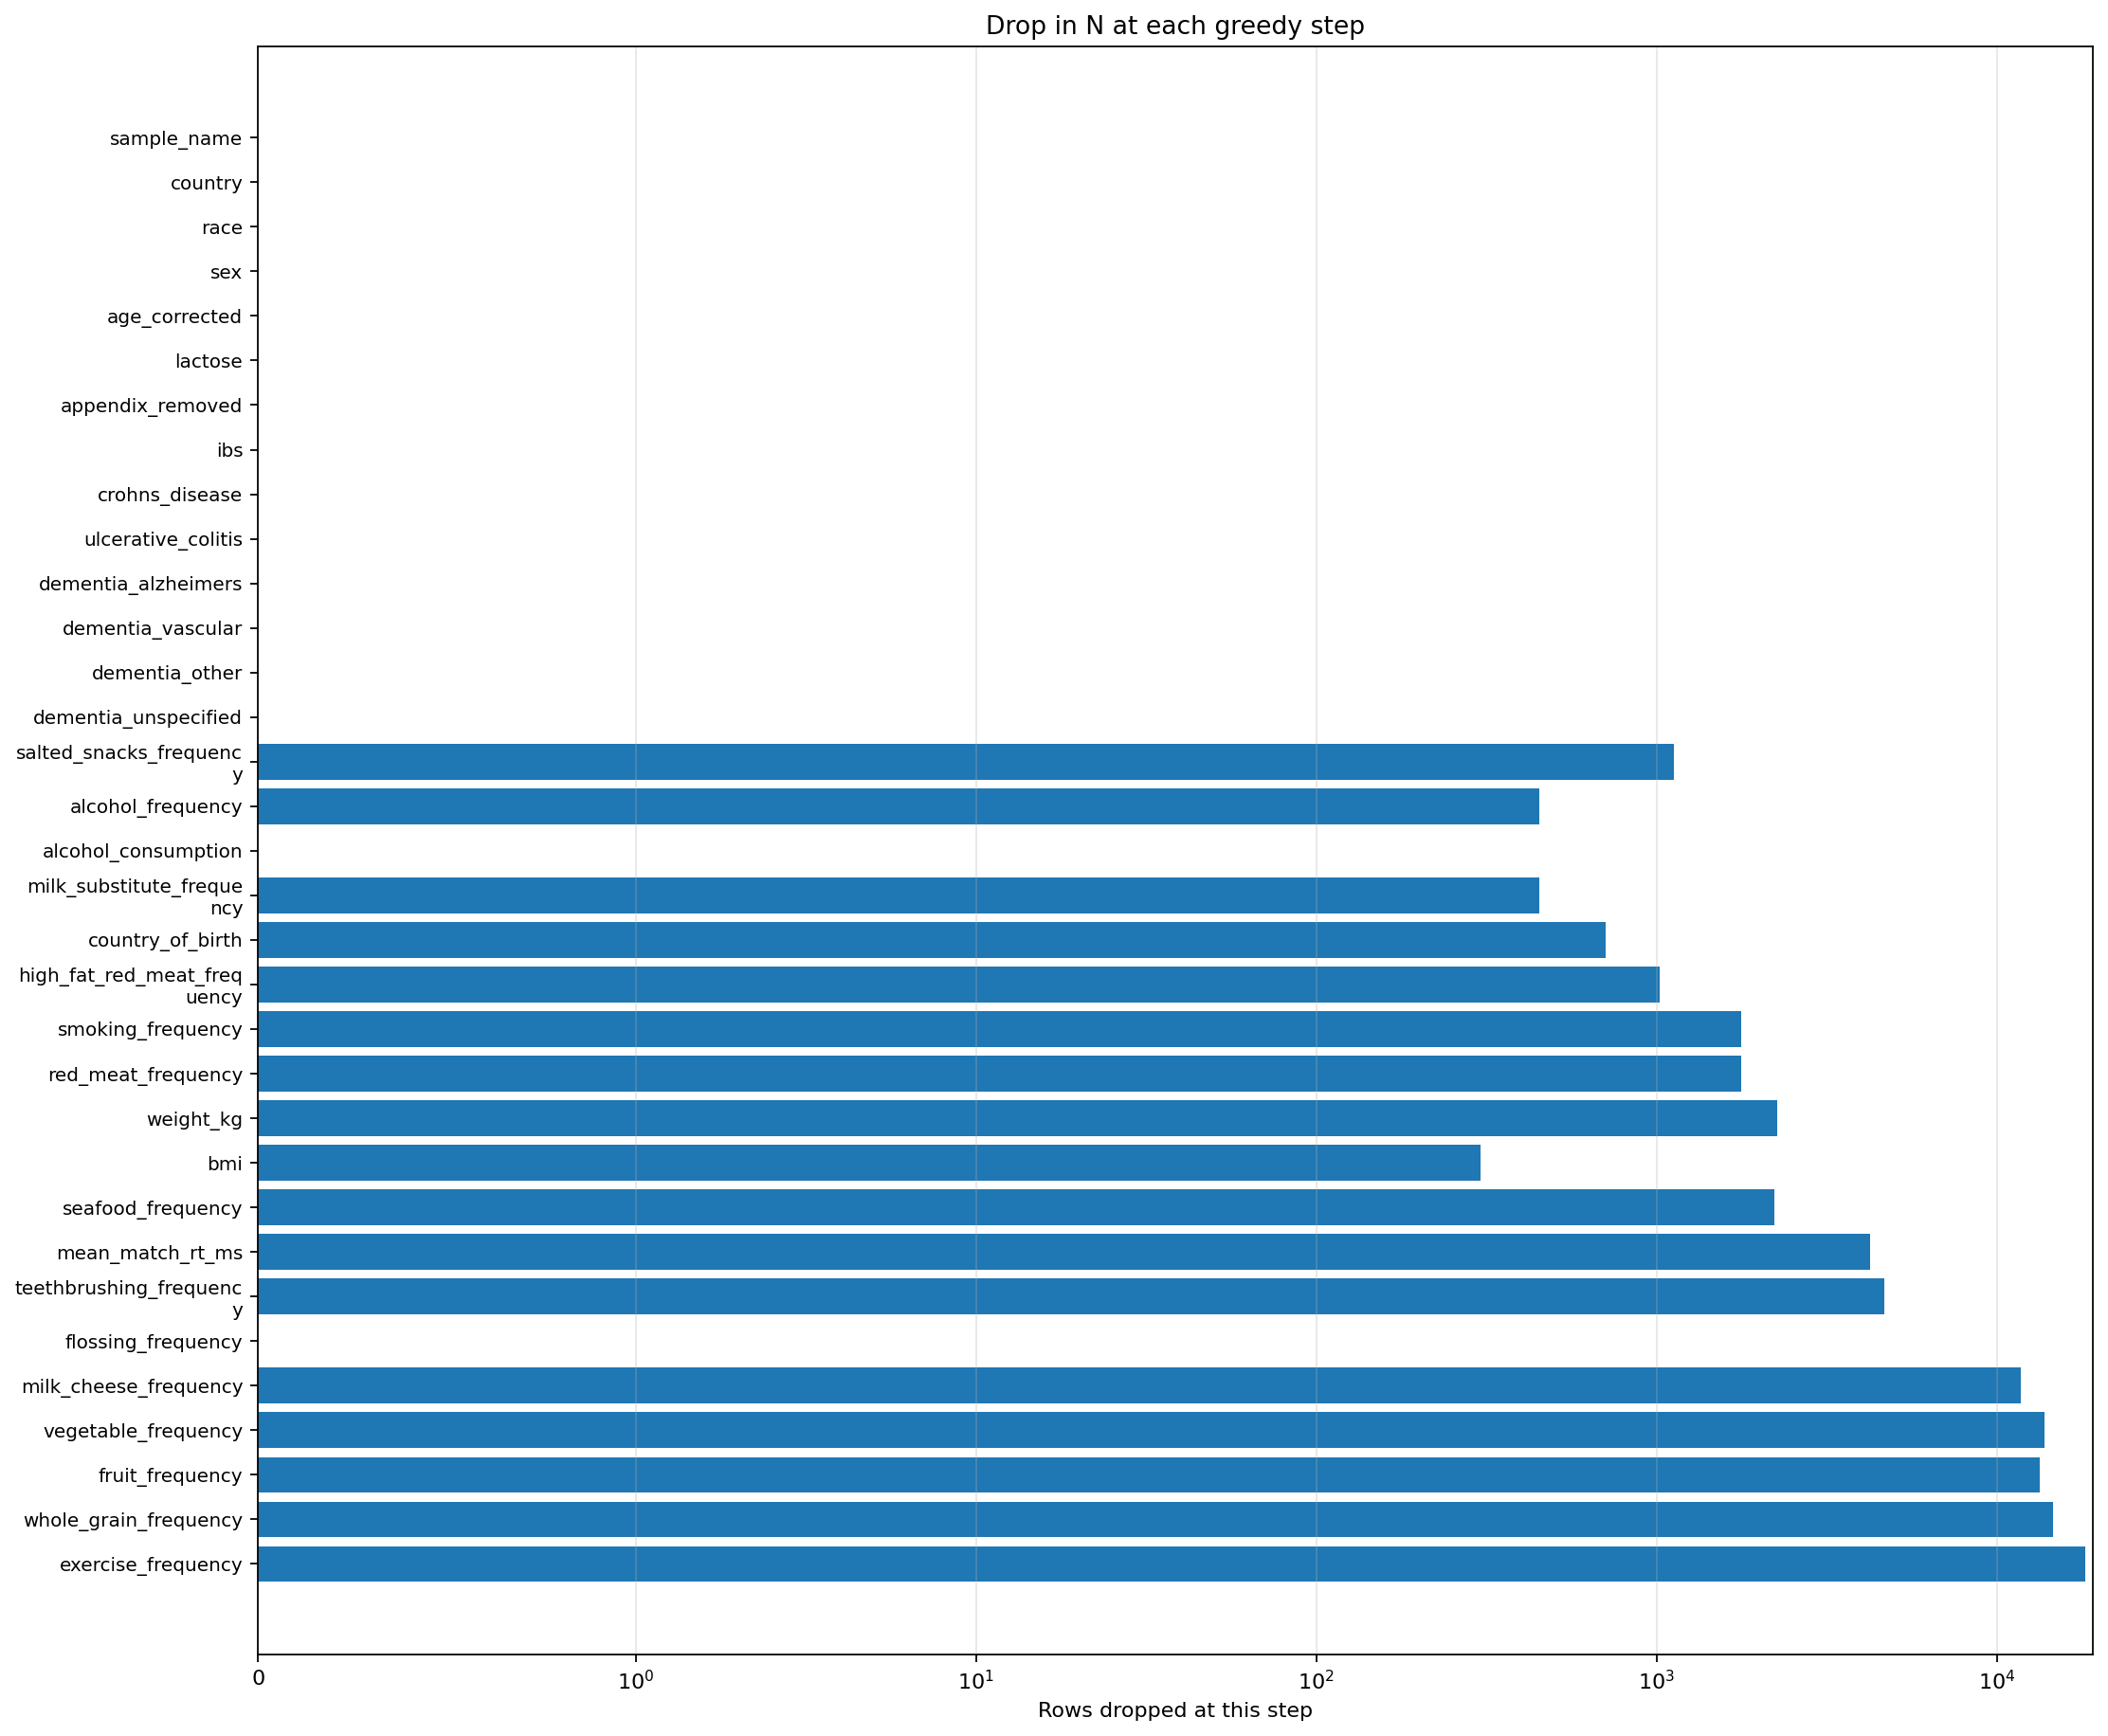

In [24]:
skip_cols = [
    "fluid_intelligence_score",
    "sugar_sweetened_drink_frequency",
    "free_sugar_scaled_0_5",
    "artificial_sweeteners",
    "one_liter_of_water_a_day_frequency",
    "olive_oil",
    "prepared_meals_frequency",
    "ready_to_eat_meals_frequency",
    "probiotic_frequency",
    "whole_eggs",
]  # whatever you want to ignore entirely

res = greedy_complete_filter(df, id_cols=["eid"], skip_cols=skip_cols)
steps_df = res["steps"]
print(steps_df)
plot_attrition(steps_df)